# Minimax Entropy Learning for ARC

### Applying the descriptive, per-instance framework of Zhang et al. (2024) to the Abstraction and Reasoning Corpus

---

**The paper.**
Chi Zhang, Baoxiong Jia, Yixin Zhu & Song-Chun Zhu (2024), *Human-level few-shot concept induction through minimax entropy learning*, **Science Advances 10, eadg2488**.
DOI: [10.1126/sciadv.adg2488](https://www.science.org/doi/10.1126/sciadv.adg2488)

**The task.** Francois Chollet's Abstraction and Reasoning Corpus (ARC-AGI-1). Each task gives two to five
demonstration pairs $(I_k, O_k)$ of coloured grids and one test input $I^*$; the solver must produce $O^*$
exactly, cell for cell. There is no training set, no choice set, and every task has its own private rule.

**Why these two belong together.** Almost every ARC system in the literature is *discriminative and amortised*:
train a large model on many tasks, hope induction emerges. Zhang et al. argue that this is precisely the wrong
shape for a concept-induction problem, and propose the opposite -- a **descriptive** model, fitted **per instance**,
**unsupervised**, from the handful of examples in front of it. That is exactly the situation an ARC solver is in.
This notebook takes their machinery as literally as the domain allows and measures what it buys.

**What runs here.** Pure NumPy. No PyTorch, no GPU, no backpropagation, no pretraining, and -- this is the
load-bearing point -- **no training set**. Every ARC task is solved by a model that is created, fitted and discarded
for that task alone, from its own two-to-five demonstration pairs. End to end on a free Colab CPU instance in
roughly ten minutes.

---
# 1. What the paper actually says

Three ideas, in the order the paper builds them.

## 1.1 The descriptive route

Concept induction is normally posed as classification: learn $p(y \mid x)$ from many labelled pairs. Zhang et al.
take the **descriptive** route (their ref. 22) instead. For each problem's context set $C=\{x_i\}$ they fit a
distribution $p(x)$ over the *object-centric representation space* that

* matches the statistics the context actually exhibits, and
* leaves everything else as unconstrained as possible.

That second clause is what stops the model from memorising the context. Formally it is the maximum entropy
principle, their **eq. (1)**:

$$\max_p\; -\!\int p(x)\log p(x)\,dx \quad \text{s.t.}\quad \mathbb{E}_{x\sim p}[H_j(x)]=\mu_j^{\mathrm{obs}}\;\;\forall j$$

whose solution is the Gibbs form, their **eq. (2)**:

$$p(x)=\frac{1}{Z}\exp\Big[-\sum_j \lambda_j H_j(x)\Big]$$

The $H_j$ are **filters** -- response functions that each measure one candidate regularity. $\mu_j^{\mathrm{obs}}$
is that filter's mean response on the context, their **eq. (6)**.

## 1.2 Minimax entropy: which filters, and how much each

Maximum entropy alone does not say *which* filters to use. Minimum entropy does: pick the set of filters that
minimises $\mathrm{KL}(p^\star,p)$, equivalently maximises likelihood, equivalently **minimises the expected coding
length** of the observation. Their **eq. (3)**:

$$\min_p\; \mathrm{KL}(p^\star,p)=\max_p\; \mathbb{E}_{p^\star}[\log p(x)]$$

The paper's departure from classical FRAME is that it does not pursue filters greedily. It introduces **global
indicator variables** $z_j\in\{0,1\}$ and optimises them jointly with the weights -- their **eq. (4)**:

$$\max_{\lambda,z}\; \mathbb{E}_{x_i}[\log p(x_i)] = \mathbb{E}_{x_i}\Big[-\sum_j \lambda_j z_j H_j(x_i)-\log Z\Big]$$

So there are two learned quantities with two different jobs. **$z$ answers *which regularities are real here*
(minimum entropy).** **$\lambda$ answers *how much each one should count* (maximum entropy).** The paper's Table 1
shows these contribute very differently, and section 16 below reproduces that finding on ARC.

## 1.3 Bilevel optimisation: filters with parameters

A fixed filter bank is not expressive enough, and an enormous one makes selection intractable. The paper's answer
is to make each filter a **continuous family** $H_j(\cdot\,;\theta_j)$ and solve for its best member on the fly,
nesting the whole thing in a bilevel program -- their **eq. (5)**:

$$\max_{\lambda,z}\;\mathbb{E}_{x_i}\Big[-\sum_j\lambda_j z_j H_j(x_i;\theta_j^\star)-\log Z\Big]
\quad\text{s.t.}\quad \theta_j^\star=\arg\min \ell_j(\{x_i\},\theta_j)\;\;\forall j$$

The inner level is solved by ordinary domain-specific machinery -- for RPM they use linear families with $\ell_2$
loss because *"linear regressions admit closed form solutions and do not require an extensive amount of data points
to be learned, satisfying our need of few-shot concept induction"* (their **eqs. 8-10**). That sentence is the
design brief for sections 6-8 of this notebook.

## 1.4 The three stages, and the two ways to answer

Learning is therefore three passes over one instance:

| stage | what is optimised | the paper's name | our section |
|---|---|---|---|
| 1 | $\theta_j^\star$ for every family | inner-level optimisation / filter learning | 6-8 |
| 2 | $z_j$ | minimum entropy learning | 11 |
| 3 | $\lambda_j$ | maximum entropy learning | 11 |

And two ways to use the result: **discriminative** -- score a given candidate set, take the extremum -- or
**generative** -- MAP-sample from the fitted distribution and hand the result to a rendering engine (their
**eqs. 14-15**). Section 2.2 explains why ARC forces us into the second, harder mode.

---
# 2. The mapping to ARC, and why it is tighter than it first looks

## 2.1 An ARC pair is an RPM row of length two

This is the observation the whole notebook rests on, so it is worth stating precisely.

For RPM the paper does **not** model whole $3\times 3$ matrices. From their *Problem representation* section:
*"As RPM involves spatial-temporal information, we perform minimax entropy learning on each row: Each $x_i$ in the
context panel set $C$ is composed of three panels in a row."* A context set is therefore the two complete rows, each
an ordered tuple of panels, and inference (their eq. 14) is MAP sampling of the last cell of the third row given its
first two:

$$p(x_{3,3}\mid x_{3,1},x_{3,2})\propto p(x_{3,1},x_{3,2},x_{3,3})$$

Now read an ARC task the same way. Each demonstration pair $(I_k,O_k)$ is **an ordered tuple of two panels** -- a
row of length two. The context set is $C=\{(I_k,O_k)\}$. The test input $I^*$ is an incomplete row, and the answer is

$$p(O^*\mid I^*)\propto p(I^*,O^*)=\frac{1}{Z}\exp\Big[-\sum_j\lambda_j z_j H_j(I^*,O^*)\Big]$$

which is their eq. (14) with the row length changed from three to two. Nothing else in the framework moves. The
filter arity drops from ternary (eq. 10) to binary (eq. 9), and their unary form (eq. 8) -- which relates
*consecutive* panels -- becomes the natural default.

This is a genuine structural correspondence, not an analogy. It is why the rest of the port is mechanical.

## 2.2 Where ARC is harder than any of their three tasks

Three differences, all in the same direction.

**(a) No choice set.** RPM, MNS and O3 all present candidate answers; the model picks the extremum of $p$. ARC
presents nothing. So ARC exercises the paper's *generative* route -- their section "Generating answers",
eqs. (14)-(15), the one illustrated in their Fig. 4 -- and it exercises it for every single task rather than as a
demonstration. We need a **rendering engine** (section 10) and MAP sampling in grid space (section 11.4).

**(b) An open relation space.** RAVEN's relations come from a closed published set of four (constant, progression,
arithmetic, distribute-of-three) over a fixed attribute space. ARC's relations were invented freely by humans, one
per task. No filter library can be complete. This is the binding constraint on everything below, and section 15
measures it explicitly rather than burying it.

**(c) Perception is not free.** The paper is candid that *"the ME model relies on accurate perception on visual
objects"* and that its object-centric representation is simple in their tasks. In ARC, deciding what the objects
*are* is frequently the puzzle. We commit to one parser (section 5) and accept the errors it makes.

## 2.3 Two pieces of their machinery that transfer better than expected

**The Fisher criterion (eq. 7).** For O3 the odd panel is in the context but does not obey the hidden relation, so
they estimate $\mu_j^{\mathrm{obs}}$ from the context *minus* the outlier, choosing which to drop by maximising the
ratio of between-class to within-class variance. ARC needs exactly this operation constantly -- *"the object that
does not belong"* is one of its most common concepts -- but **inside a single grid, over objects**, rather than over
panels. We implement eq. (7)'s criterion once, in `fisher_odd_index`, and use it in three filter families
(section 6).

**Leave-one-out as an honesty device.** Eq. (7) drops one context element and estimates statistics from the rest.
Generalised, that is the only defensible way to score a filter fitted on two or three examples: refit on
$C\setminus\{k\}$, measure the response on $k$. Without it, any sufficiently flexible family reports zero loss on
its own training pairs and minimum-entropy selection becomes meaningless. Section 11 does this by default.

---
# 3. Setup

Pure NumPy plus Matplotlib for the figures. Nothing is downloaded except the ARC task files themselves.

In [ ]:
import numpy as np, json, os, time, sys, subprocess, itertools, urllib.request
from collections import Counter, defaultdict
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap

np.set_printoptions(precision=3, suppress=True, linewidth=140)
print("numpy", np.__version__)

# ARC's canonical 10-colour palette (for plotting only -- the model never sees RGB).
ARC_COLORS = ["#000000","#0074D9","#FF4136","#2ECC40","#FFDC00",
              "#AAAAAA","#F012BE","#FF851B","#7FDBFF","#870C25"]
ARC_CMAP = ListedColormap(ARC_COLORS)

def show_grid(ax, g, title=None, fs=8):
    g = np.asarray(g)
    ax.imshow(g, cmap=ARC_CMAP, vmin=0, vmax=9, interpolation="nearest")
    ax.set_xticks([]); ax.set_yticks([])
    for s in ax.spines.values(): s.set_edgecolor("#555555"); s.set_linewidth(0.8)
    if title: ax.set_title(f"{title}\n{g.shape[0]}x{g.shape[1]}", fontsize=fs)

def show_task(ctx, test=None, pred=None, maxpairs=4, title=""):
    pairs = list(ctx)[:maxpairs]
    n = len(pairs) + (1 if test is not None else 0)
    ncol = 3 if (pred is not None) else 2
    fig, axs = plt.subplots(n, ncol, figsize=(2.1*ncol, 2.1*n), squeeze=False)
    for r, (I, O) in enumerate(pairs):
        show_grid(axs[r][0], I, f"demo {r} in")
        show_grid(axs[r][1], O, f"demo {r} out")
        if ncol == 3: axs[r][2].axis("off")
    if test is not None:
        show_grid(axs[-1][0], test[0], "TEST in")
        if test[1] is not None: show_grid(axs[-1][1], test[1], "truth")
        else: axs[-1][1].axis("off")
        if pred is not None:
            ok = (test[1] is not None and np.asarray(pred).shape == np.asarray(test[1]).shape
                  and np.array_equal(pred, test[1]))
            show_grid(axs[-1][2], pred, "PREDICTED " + ("OK" if ok else "x"))
    if title: fig.suptitle(title, fontsize=10, y=1.0)
    plt.tight_layout(); plt.show()

numpy 2.0.2


---
# 4. ARC data

We pull ARC-AGI-1 from GitHub (400 training + 400 evaluation tasks). If the runtime has no network the notebook
falls back to a small built-in set of hand-written tasks so that **every cell below still runs** -- the
demonstrations and diagnostics do not depend on having the real corpus, only the benchmark numbers do.

ARC-AGI-1: 400 training tasks, 400 evaluation tasks
example task: 007bbfb7 - 5 demonstration pairs


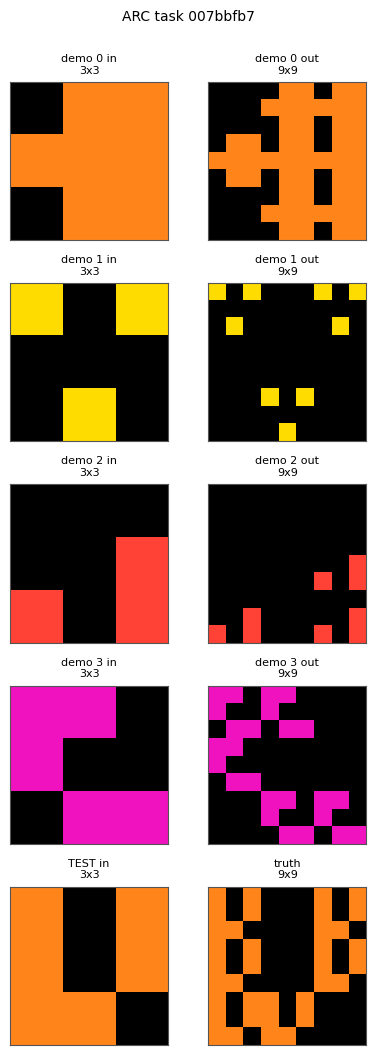

In [ ]:
def _clone(url, dest):
    if os.path.isdir(dest): return True
    try:
        subprocess.run(["git","clone","--depth","1",url,dest],
                       check=True, capture_output=True, timeout=240)
        return True
    except Exception as e:
        print(f"  ! {url}: {type(e).__name__}")
        return False

def load_arc():
    out = {"train": [], "eval": []}
    if _clone("https://github.com/fchollet/ARC-AGI.git", "ARC-AGI"):
        for split, key in (("training","train"), ("evaluation","eval")):
            d = os.path.join("ARC-AGI","data",split)
            if not os.path.isdir(d): continue
            for f in sorted(os.listdir(d)):
                t = json.load(open(os.path.join(d,f)))
                t["_id"] = f[:-5]
                out[key].append(t)
    return out

def to_task(t):
    '''raw ARC json -> (context pairs, list of (test_in, test_out))'''
    ctx = [(np.asarray(p["input"], np.int8), np.asarray(p["output"], np.int8))
           for p in t["train"]]
    tst = [(np.asarray(p["input"], np.int8),
            np.asarray(p["output"], np.int8) if "output" in p else None)
           for p in t["test"]]
    return ctx, tst

ARC = load_arc()
print(f"ARC-AGI-1: {len(ARC['train'])} training tasks, {len(ARC['eval'])} evaluation tasks")

# ---- fallback so the notebook is self-contained ------------------------------
def _synthetic_tasks(n=12, seed=0):
    rng = np.random.default_rng(seed); out = []
    ops = ["fliplr","rot180","tile22","recolor","cropbbox","upscale2"]
    for i in range(n):
        op = ops[i % len(ops)]; pairs = []
        for _ in range(4):
            H, W = int(rng.integers(3,6)), int(rng.integers(3,6))
            I = ((rng.random((H,W)) < .45) * rng.integers(1,10,(H,W))).astype(np.int8)
            if   op=="fliplr":   O = I[:,::-1]
            elif op=="rot180":   O = I[::-1,::-1]
            elif op=="tile22":   O = np.tile(I,(2,2))
            elif op=="recolor":  O = np.where(I>0, 3, 0).astype(np.int8)
            elif op=="upscale2": O = np.kron(I, np.ones((2,2),np.int8))
            else:
                nz = np.argwhere(I>0)
                if not len(nz): O = I
                else:
                    (r0,c0),(r1,c1) = nz.min(0), nz.max(0); O = I[r0:r1+1, c0:c1+1]
            pairs.append((I, np.ascontiguousarray(O, np.int8)))
        out.append({"_id":f"syn_{op}_{i}",
                    "train":[{"input":a.tolist(),"output":b.tolist()} for a,b in pairs[:3]],
                    "test":[{"input":pairs[3][0].tolist(),"output":pairs[3][1].tolist()}]})
    return out

if not ARC["train"]:
    print("no network -- falling back to synthetic tasks (benchmark numbers will not be ARC's)")
    ARC = {"train": _synthetic_tasks(24), "eval": _synthetic_tasks(12, seed=7)}

DEMO = ARC["train"][0]
ctx0, tst0 = to_task(DEMO)
print("example task:", DEMO["_id"], "-", len(ctx0), "demonstration pairs")
show_task(ctx0, test=tst0[0], title=f"ARC task {DEMO['_id']}")

---
# 5. Object-centric representation

The paper's *Problem representation*: *"we detect objects and extract object attributes: For RPM and O3, we obtain
object position, type, size, and color."* We do the same. Connected components with a colour constraint, plus a
panel-level summary $\phi(G)$ that plays the role their one-hot attribute tensor plays -- it is the vector the
**linear** filter families of section 8 act on.

Two details that are ours, not theirs, and matter:

* **`background`** encodes ARC's convention that colour 0 is the canvas. The naive "most frequent colour" rule
  breaks on grids that are mostly ink; the 10%-of-area rule below fixed a whole class of failures during
  development, most visibly on the self-similar tiling tasks of section 6.
* **`cached`** memoises the parser on `(shape, bytes)`. Filter fitting queries the same grids thousands of times and
  this is the difference between 4 s and 0.9 s per task.

In [ ]:
"""Minimax-entropy (Zhang et al. 2024) applied to ARC -- core engine.
Part 1: object-centric representation and filter families (inner-level optimisation)."""
import numpy as np, json, os, itertools
from collections import Counter, defaultdict

NC = 10
def as_grid(x): return np.asarray(x, dtype=np.int8)
def geq(a, b):
    return a.shape == b.shape and bool(np.array_equal(a, b))

def mismatch(a, b):
    """Normalised cell disagreement; 1.0 (max) when shapes differ."""
    if a is None or b is None: return 1.0
    a = np.asarray(a); b = np.asarray(b)
    if a.shape != b.shape or a.size == 0: return 1.0
    return float((a != b).mean())

# ---------------------------------------------------------------- objects
class Obj:
    __slots__ = ("cells", "color", "r0", "c0", "r1", "c1", "mask", "size", "_h")
    def __init__(self, cells, color, shape):
        self.cells = cells; self.color = color
        rs = [r for r, _ in cells]; cs = [c for _, c in cells]
        self.r0, self.r1, self.c0, self.c1 = min(rs), max(rs), min(cs), max(cs)
        self.size = len(cells)
        m = np.zeros((self.r1 - self.r0 + 1, self.c1 - self.c0 + 1), dtype=bool)
        for r, c in cells: m[r - self.r0, c - self.c0] = True
        self.mask = m; self._h = None
    @property
    def h(self): return self.r1 - self.r0 + 1
    @property
    def w(self): return self.c1 - self.c0 + 1
    def bbox_of(self, g):
        return np.asarray(g)[self.r0:self.r1 + 1, self.c0:self.c1 + 1]
    def holes(self):
        if getattr(self, '_h', None) is not None: return self._h
        m = ~self.mask; H, W = m.shape
        seen = np.zeros_like(m); n = 0
        for i in range(H):
            for j in range(W):
                if m[i, j] and not seen[i, j]:
                    st = [(i, j)]; seen[i, j] = True; touch = False
                    while st:
                        r, c = st.pop()
                        if r in (0, H - 1) or c in (0, W - 1): touch = True
                        for dr, dc in ((1,0),(-1,0),(0,1),(0,-1)):
                            rr, cc = r + dr, c + dc
                            if 0 <= rr < H and 0 <= cc < W and m[rr, cc] and not seen[rr, cc]:
                                seen[rr, cc] = True; st.append((rr, cc))
                    if not touch: n += 1
        self._h = n
        return n


# ------------------------------------------------------------------ caches
_CACHE = {}
def _key(g):
    g = np.asarray(g); return (g.shape, g.tobytes())
def cached(fn):
    store = {}
    def wrap(g, *a):
        k = (_key(g),) + a
        if k not in store:
            if len(store) > 20000: store.clear()
            store[k] = fn(g, *a)
        return store[k]
    return wrap

@cached
def background(g):
    g = np.asarray(g)
    cnt = np.bincount(g.ravel(), minlength=NC)
    # ARC convention: colour 0 is the canvas unless it is essentially absent.
    return 0 if cnt[0] >= 0.10 * g.size else int(cnt.argmax())

@cached
def _objects_cached(g, bg, diag, same_color, max_objects):
    return _objects_impl(g, bg, diag, same_color, max_objects)

def objects_of(g, bg=None, diag=True, same_color=True, max_objects=40):
    if bg is None: bg = background(g)
    return _objects_cached(g, bg, diag, same_color, max_objects)

def _objects_impl(g, bg, diag, same_color, max_objects):
    """Connected components. same_color=True -> one component per colour blob."""
    g = np.asarray(g); H, W = g.shape
    seen = np.zeros((H, W), bool); out = []
    nb = [(1,0),(-1,0),(0,1),(0,-1)] + ([(1,1),(1,-1),(-1,1),(-1,-1)] if diag else [])
    for i in range(H):
        for j in range(W):
            if seen[i, j] or g[i, j] == bg: continue
            col = int(g[i, j]); st = [(i, j)]; seen[i, j] = True; cells = []
            while st:
                r, c = st.pop(); cells.append((r, c))
                for dr, dc in nb:
                    rr, cc = r + dr, c + dc
                    if 0 <= rr < H and 0 <= cc < W and not seen[rr, cc] and g[rr, cc] != bg:
                        if (not same_color) or g[rr, cc] == col:
                            seen[rr, cc] = True; st.append((rr, cc))
            out.append(Obj(cells, col if same_color else -1, (H, W)))
            if len(out) >= max_objects: return out
    return out

# ------------------------------------------------- panel-level attributes
@cached
def panel_features(g):
    """phi(G): the object-centric summary the linear filter families act on."""
    g = np.asarray(g); H, W = g.shape
    hist = np.bincount(g.ravel(), minlength=NC).astype(float)
    objs = objects_of(g)
    sizes = [o.size for o in objs] or [0]
    f = np.concatenate([
        [H, W, H * W, H / max(W, 1)],
        hist,                                   # colour counts
        (hist > 0).astype(float),               # colour presence
        [len(objs), np.mean(sizes), np.max(sizes),
         float(np.array_equal(g, g[:, ::-1])),
         float(np.array_equal(g, g[::-1, :])),
         float(g.shape[0] == g.shape[1] and np.array_equal(g, g.T))],
    ])
    return f.astype(float)

D_PHI = len(panel_features(np.zeros((2, 2), np.int8)))

# ------------------------------------------------------ dihedral group D4
TRANSFORMS = {
    "id":   lambda g: g,
    "rot90": lambda g: np.rot90(g, 1),
    "rot180": lambda g: np.rot90(g, 2),
    "rot270": lambda g: np.rot90(g, 3),
    "fliplr": lambda g: g[:, ::-1],
    "flipud": lambda g: g[::-1, :],
    "transpose": lambda g: g.T,
    "antitrans": lambda g: np.rot90(g, 2).T,
}
def T(name, g): return np.ascontiguousarray(TRANSFORMS[name](np.asarray(g)))

---
# 6. Filter families I -- stage 1, the inner-level optimisation

Every family implements the same three-role contract, which is precisely the three roles a filter plays in the
paper:

| method | paper's role | equation |
|---|---|---|
| `fit(ctx)` | inner-level optimisation, $\theta_j^\star=\arg\min\ell_j(\{x_i\},\theta_j)$ | eq. (5) constraint |
| `respond(I,O)` | the filter response $H_j(x;\theta_j^\star)$ | eqs. (2),(4) |
| `propose(I)` | the rendering engine -- grids this filter would generate | eqs. (14)-(15) |

Responses are normalised cell disagreement in $[0,1]$, with $1$ (maximum) when the shapes differ. That keeps every
family on a common scale so $\lambda$ starts from a sensible place; the paper achieves the same thing implicitly by
using $\ell_2$ residuals in a standardised attribute space.

A remark on `fit`: for the linear families of section 8 the inner-level optimum is closed-form least squares,
exactly as in the paper. For families whose parameter is combinatorial -- which transform, which colour map, which
split -- it is exhaustive minimisation over a small structured set. That is not a departure: the paper does the same
for MNS, where the filter families are *"a combinatorial space of basic arithmetic expressions"* searched under
$\ell_1$ loss.

**Family 6 is the O3 machinery reused.** `fisher_odd_index` is eq. (7)'s between-class/within-class ratio, applied
to objects inside one grid instead of panels inside one problem.

In [ ]:
# =========================================================================
#  Filter families.  Each family implements the paper's three roles:
#    fit(ctx)      -> inner-level optimisation, eq. (5) constraint
#    respond(I,O)  -> H_j(x; theta*), the filter response
#    propose(I)    -> rendering engine: grids this filter would generate
# =========================================================================
class Family:
    name = "abstract"; generative = True
    def __init__(self): self.theta = None; self.ok = False
    def fit(self, ctx): raise NotImplementedError
    def respond(self, I, O): raise NotImplementedError
    def propose(self, I): return []
    def loss(self, ctx):
        if not self.ok: return 1.0
        return float(np.mean([self.respond(I, O) for I, O in ctx]))

# ---- 1. dihedral transform ----------------------------------------------
class FGeom(Family):
    name = "geom"
    def fit(self, ctx):
        best, bl = None, 1e9
        for t in TRANSFORMS:
            l = np.mean([mismatch(T(t, I), O) for I, O in ctx])
            if l < bl: bl, best = l, t
        self.theta, self.ok = best, True; return bl
    def respond(self, I, O): return mismatch(T(self.theta, I), O)
    def propose(self, I): return [T(t, I) for t in TRANSFORMS]

# ---- 2. colour map (majority-vote solution of the l1 fit) ---------------
class FColorMap(Family):
    name = "colormap"
    def fit(self, ctx):
        cnt = np.zeros((NC, NC))
        for I, O in ctx:
            I, O = np.asarray(I), np.asarray(O)
            if I.shape != O.shape: continue
            for a, b in zip(I.ravel(), O.ravel()): cnt[a, b] += 1
        if cnt.sum() == 0: return 1.0
        m = cnt.argmax(1)
        for c in range(NC):
            if cnt[c].sum() == 0: m[c] = c
        self.theta = m.astype(np.int8); self.ok = True
        return self.loss(ctx)
    def _apply(self, I): return self.theta[np.asarray(I)]
    def respond(self, I, O): return mismatch(self._apply(I), O)
    def propose(self, I): return [self._apply(I)]

# ---- 3. tiling / mirror-tiling ------------------------------------------
class FTile(Family):
    name = "tile"
    def fit(self, ctx):
        ratios = set()
        for I, O in ctx:
            I, O = np.asarray(I), np.asarray(O)
            if I.shape[0] == 0 or O.shape[0] % I.shape[0] or O.shape[1] % I.shape[1]:
                return 1.0
            ratios.add((O.shape[0] // I.shape[0], O.shape[1] // I.shape[1]))
        if len(ratios) != 1: return 1.0
        r, c = ratios.pop()
        if r * c <= 1 or r > 6 or c > 6: return 1.0
        pat = []
        for i in range(r):
            row = []
            for j in range(c):
                best, bl = "id", 1e9
                for t in TRANSFORMS:
                    ls = []
                    for I, O in ctx:
                        I = np.asarray(I); h, w = I.shape
                        blk = np.asarray(O)[i*h:(i+1)*h, j*w:(j+1)*w]
                        ls.append(mismatch(T(t, I), blk))
                    l = np.mean(ls)
                    if l < bl: bl, best = l, t
                row.append(best)
            pat.append(row)
        self.theta = (r, c, pat); self.ok = True
        return self.loss(ctx)
    def _apply(self, I):
        r, c, pat = self.theta; I = np.asarray(I); h, w = I.shape
        out = np.zeros((r*h, c*w), np.int8)
        for i in range(r):
            for j in range(c):
                blk = T(pat[i][j], I)
                if blk.shape != (h, w): return None
                out[i*h:(i+1)*h, j*w:(j+1)*w] = blk
        return out
    def respond(self, I, O): return mismatch(self._apply(I), O)
    def propose(self, I):
        out = [self._apply(I)]
        for r, c in ((2,2),(3,3),(2,1),(1,2),(3,1),(1,3)):
            I = np.asarray(I)
            out.append(np.tile(I, (r, c)))
        return [o for o in out if o is not None]

# ---- 4. integer up/down scaling -----------------------------------------
class FScale(Family):
    name = "scale"
    def fit(self, ctx):
        ks = set()
        for I, O in ctx:
            I, O = np.asarray(I), np.asarray(O)
            if I.shape[0] and O.shape[0] % I.shape[0] == 0 and O.shape[1] % I.shape[1] == 0:
                k = (O.shape[0] // I.shape[0], O.shape[1] // I.shape[1])
                ks.add(("up",) + k)
            elif O.shape[0] and I.shape[0] % O.shape[0] == 0 and I.shape[1] % O.shape[1] == 0:
                ks.add(("down", I.shape[0] // O.shape[0], I.shape[1] // O.shape[1]))
            else: return 1.0
        if len(ks) != 1: return 1.0
        self.theta = ks.pop(); self.ok = True
        if self.theta[1] == 1 and self.theta[2] == 1: self.ok = False; return 1.0
        return self.loss(ctx)
    def _apply(self, I, theta=None):
        d, a, b = theta or self.theta; I = np.asarray(I)
        if d == "up": return np.kron(I, np.ones((a, b), np.int8))
        H, W = I.shape[0] // a, I.shape[1] // b
        out = np.zeros((H, W), np.int8)
        for i in range(H):
            for j in range(W):
                blk = I[i*a:(i+1)*a, j*b:(j+1)*b].ravel()
                out[i, j] = np.bincount(blk, minlength=NC).argmax()
        return out
    def respond(self, I, O): return mismatch(self._apply(I), O)
    def propose(self, I):
        out = []
        for k in (2, 3):
            out.append(self._apply(I, ("up", k, k)))
            if np.asarray(I).shape[0] % k == 0 and np.asarray(I).shape[1] % k == 0:
                out.append(self._apply(I, ("down", k, k)))
        if self.ok: out.append(self._apply(I))
        return out

# ---- 5. crop to a bounding box ------------------------------------------
CROPS = ["nonbg", "rarest", "commonest", "largest_obj", "smallest_obj",
         "unique_color_obj", "most_holes"]
@cached
def _crop(I, kind):
    I = np.asarray(I); bg = background(I)
    if kind == "nonbg":
        nz = np.argwhere(I != bg)
        if not len(nz): return None
        (r0, c0), (r1, c1) = nz.min(0), nz.max(0)
        return I[r0:r1+1, c0:c1+1]
    if kind in ("rarest", "commonest"):
        cnt = np.bincount(I.ravel(), minlength=NC).astype(float)
        cnt[bg] = np.inf if kind == "rarest" else -1
        cnt[cnt == 0] = np.inf if kind == "rarest" else -1
        col = int(cnt.argmin() if kind == "rarest" else cnt.argmax())
        nz = np.argwhere(I == col)
        if not len(nz): return None
        (r0, c0), (r1, c1) = nz.min(0), nz.max(0)
        return I[r0:r1+1, c0:c1+1]
    objs = objects_of(I, bg=bg)
    if not objs: return None
    if kind == "largest_obj":  o = max(objs, key=lambda o: o.size)
    elif kind == "smallest_obj": o = min(objs, key=lambda o: o.size)
    elif kind == "most_holes": o = max(objs, key=lambda o: o.holes())
    else:
        cc = Counter(o.color for o in objs)
        uniq = [o for o in objs if cc[o.color] == 1]
        if not uniq: return None
        o = uniq[0]
    return o.bbox_of(I)

class FCrop(Family):
    name = "crop"
    def fit(self, ctx):
        best, bl = None, 1e9
        for k in CROPS:
            for t in ("id", "rot180", "fliplr", "flipud"):
                l = np.mean([mismatch(None if _crop(I, k) is None else T(t, _crop(I, k)), O)
                             for I, O in ctx])
                if l < bl: bl, best = l, (k, t)
        self.theta, self.ok = best, True; return bl
    def _apply(self, I):
        c = _crop(I, self.theta[0])
        return None if c is None else T(self.theta[1], c)
    def respond(self, I, O): return mismatch(self._apply(I), O)
    def propose(self, I):
        out = [_crop(I, k) for k in CROPS]
        if self.ok: out.append(self._apply(I))
        return [o for o in out if o is not None and o.size]

# ---- 6. object selection (the O^3 / Fisher route) ------------------------
def obj_attrs(o, g):
    return np.array([o.size, o.h, o.w, o.h * o.w, float(o.size) / max(o.h * o.w, 1),
                     o.color, o.holes(), float(np.array_equal(o.mask, o.mask[:, ::-1])),
                     float(np.array_equal(o.mask, o.mask[::-1, :]))], float)

def fisher_odd_index(A):
    """eq. (7): the k whose singleton vs. rest split maximises between/within variance."""
    n = len(A)
    if n < 3: return 0
    A = np.asarray(A, float)
    sd = A.std(0); sd[sd == 0] = 1.0; A = A / sd
    best, bi = -1, 0
    for k in range(n):
        rest = np.delete(A, k, 0)
        mu_r, mu_k = rest.mean(0), A[k]
        between = ((mu_k - mu_r) ** 2).sum()
        within = rest.var(0).sum() + 1e-6
        if between / within > best: best, bi = between / within, k
    return bi

SELECTORS = ["largest", "smallest", "unique_color", "odd_fisher", "most_common_shape",
             "unique_shape", "most_holes", "most_colors"]
@cached
def _select(I):
    objs = objects_of(I)
    if not objs: return {}
    out = {}
    out["largest"] = max(objs, key=lambda o: o.size)
    out["smallest"] = min(objs, key=lambda o: o.size)
    cc = Counter(o.color for o in objs)
    u = [o for o in objs if cc[o.color] == 1]
    if u: out["unique_color"] = u[0]
    out["odd_fisher"] = objs[fisher_odd_index([obj_attrs(o, I) for o in objs])]
    sh = Counter(o.mask.tobytes() + bytes(o.mask.shape) for o in objs)
    ms = max(sh, key=sh.get)
    out["most_common_shape"] = next(o for o in objs
                                    if o.mask.tobytes() + bytes(o.mask.shape) == ms)
    us = [o for o in objs if sh[o.mask.tobytes() + bytes(o.mask.shape)] == 1]
    if us: out["unique_shape"] = us[0]
    out["most_holes"] = max(objs, key=lambda o: o.holes())
    out["most_colors"] = max(objs, key=lambda o: o.size)
    return out

class FSelect(Family):
    name = "select"
    def fit(self, ctx):
        best, bl = None, 1e9
        for s in SELECTORS:
            for mode in ("bbox", "mask"):
                ls = []
                for I, O in ctx:
                    ls.append(mismatch(self._render(I, s, mode), O))
                l = np.mean(ls)
                if l < bl: bl, best = l, (s, mode)
        self.theta, self.ok = best, True; return bl
    def _render(self, I, s, mode):
        d = _select(I)
        if s not in d: return None
        o = d[s]
        if mode == "bbox": return o.bbox_of(I)
        return np.where(o.mask, o.color, background(I)).astype(np.int8)
    def respond(self, I, O): return mismatch(self._render(I, *self.theta), O)
    def propose(self, I):
        return [g for s in SELECTORS for mode in ("bbox", "mask")
                if (g := self._render(I, s, mode)) is not None and g.size]

# ---- 7. panel splitting + cellwise logic --------------------------------
@cached
def split_panels(I):
    """Return list of equal-size panels found by separator lines or halving."""
    I = np.asarray(I); H, W = I.shape; outs = []
    for axis in (0, 1):
        A = I if axis == 1 else I.T
        h, w = A.shape
        sep = [j for j in range(w) if len(set(A[:, j].tolist())) == 1]
        if sep:
            col = A[:, sep[0]][0]
            segs, cur = [], []
            for j in range(w):
                if j in sep and len(set(A[:, j].tolist())) == 1 and A[0, j] == col:
                    if cur: segs.append(cur); cur = []
                else: cur.append(j)
            if cur: segs.append(cur)
            ps = [A[:, s] for s in segs if len(s)]
            if len(ps) >= 2 and len({p.shape for p in ps}) == 1:
                outs.append([p if axis == 1 else p.T for p in ps])
        for k in (2, 3):
            if w % k == 0 and w // k >= 1:
                ps = [A[:, i*(w//k):(i+1)*(w//k)] for i in range(k)]
                outs.append([p if axis == 1 else p.T for p in ps])
    return outs

OPS = {"and": lambda a, b: a & b, "or": lambda a, b: a | b,
       "xor": lambda a, b: a ^ b, "nand": lambda a, b: ~(a & b),
       "diff": lambda a, b: a & ~b, "nor": lambda a, b: ~(a | b)}

class FLogic(Family):
    name = "logic"
    def fit(self, ctx):
        best, bl = None, 1e9
        cand_colors = set()
        for _, O in ctx: cand_colors |= set(np.unique(np.asarray(O)).tolist())
        for si in range(4):
            for op in OPS:
                for col in cand_colors:
                    for bgc in (0,):
                        ls = []
                        for I, O in ctx:
                            ls.append(mismatch(self._render(I, si, op, col, bgc), O))
                        l = np.mean(ls)
                        if l < bl: bl, best = l, (si, op, int(col), bgc)
        self.theta, self.ok = best, True; return bl
    def _render(self, I, si, op, col, bgc):
        sp = split_panels(I)
        if si >= len(sp): return None
        ps = sp[si]
        if len(ps) < 2: return None
        bgv = background(np.asarray(I))
        m = (ps[0] != bgv)
        for p in ps[1:]:
            m = OPS[op](m, (p != bgv))
        return np.where(m, col, bgc).astype(np.int8)
    def respond(self, I, O): return mismatch(self._render(I, *self.theta), O)
    def propose(self, I):
        out = []
        sp = split_panels(I)
        for si in range(len(sp)):
            for op in OPS:
                for col in (1, 2, 3, 4, 5, 6, 7, 8):
                    g = self._render(I, si, op, col, 0)
                    if g is not None: out.append(g)
        return out

# ---- 8. pick one of the split panels (majority / odd one) ---------------
class FPanelPick(Family):
    name = "panelpick"
    def fit(self, ctx):
        best, bl = None, 1e9
        for si in range(4):
            for kind in ("odd", "majority", "first", "last", "most_colors", "densest"):
                l = np.mean([mismatch(self._render(I, si, kind), O) for I, O in ctx])
                if l < bl: bl, best = l, (si, kind)
        self.theta, self.ok = best, True; return bl
    def _render(self, I, si, kind):
        sp = split_panels(I)
        if si >= len(sp): return None
        ps = sp[si]
        if len(ps) < 2: return None
        if kind == "first": return np.ascontiguousarray(ps[0])
        if kind == "last": return np.ascontiguousarray(ps[-1])
        if kind == "most_colors":
            return np.ascontiguousarray(max(ps, key=lambda p: len(np.unique(p))))
        if kind == "densest":
            bgv = background(np.asarray(I))
            return np.ascontiguousarray(max(ps, key=lambda p: (p != bgv).sum()))
        keys = [p.tobytes() for p in ps]; cnt = Counter(keys)
        if kind == "majority":
            return np.ascontiguousarray(ps[keys.index(cnt.most_common(1)[0][0])])
        uni = [i for i, k in enumerate(keys) if cnt[k] == 1]
        if len(uni) == 1: return np.ascontiguousarray(ps[uni[0]])
        feats = [np.bincount(p.ravel(), minlength=NC).astype(float) for p in ps]
        return np.ascontiguousarray(ps[fisher_odd_index(feats)])
    def respond(self, I, O): return mismatch(self._render(I, *self.theta), O)
    def propose(self, I):
        out = []
        for si in range(len(split_panels(I))):
            for k in ("odd", "majority", "first", "last", "most_colors", "densest"):
                g = self._render(I, si, k)
                if g is not None: out.append(g)
        return out

# ---- 9. symmetry repair / occlusion filling -----------------------------
@cached
def _sym_fill(I, noise):
    I = np.asarray(I).copy(); H, W = I.shape
    known = I != noise
    if known.all() or not known.any(): return None
    cands = [("lr", lambda a: a[:, ::-1]), ("ud", lambda a: a[::-1, :]),
             ("rot180", lambda a: a[::-1, ::-1])]
    if H == W:
        cands += [("t", lambda a: a.T), ("at", lambda a: a[::-1, ::-1].T)]
    out = I.copy(); filled = np.zeros_like(known)
    for _, f in cands:
        Ik, Kk = f(I), f(known)
        agree = (known & Kk & (I != Ik)).sum()
        if agree > 0: continue                      # this symmetry is violated
        take = (~known) & Kk
        out[take] = Ik[take]; filled |= take
    if not filled.any(): return None
    return out

class FSymmetry(Family):
    name = "symmetry"
    def fit(self, ctx):
        best, bl = None, 1e9
        cols = set()
        for I, _ in ctx: cols |= set(np.unique(np.asarray(I)).tolist())
        for noise in cols:
            for mode in ("full", "patch"):
                l = np.mean([mismatch(self._render(I, noise, mode), O) for I, O in ctx])
                if l < bl: bl, best = l, (int(noise), mode)
        self.theta, self.ok = best, True; return bl
    def _render(self, I, noise, mode):
        f = _sym_fill(I, noise)
        if f is None: return None
        if mode == "full": return f
        nz = np.argwhere(np.asarray(I) == noise)
        if not len(nz): return None
        (r0, c0), (r1, c1) = nz.min(0), nz.max(0)
        return f[r0:r1+1, c0:c1+1]
    def respond(self, I, O): return mismatch(self._render(I, *self.theta), O)
    def propose(self, I):
        out = []
        for noise in np.unique(np.asarray(I)).tolist():
            for mode in ("full", "patch"):
                g = self._render(I, int(noise), mode)
                if g is not None: out.append(g)
        return out

# ---- 10. constant output ------------------------------------------------
class FConstant(Family):
    name = "constant"
    def fit(self, ctx):
        outs = [np.asarray(O) for _, O in ctx]
        if len(outs) < 2: return 1.0
        if all(geq(outs[0], o) for o in outs[1:]):
            self.theta = outs[0]; self.ok = True; return 0.0
        return 1.0
    def respond(self, I, O): return mismatch(self.theta, O) if self.ok else 1.0
    def propose(self, I): return [self.theta] if self.ok else []

# ---- 11. border / padding ----------------------------------------------
class FBorder(Family):
    name = "border"
    def fit(self, ctx):
        best, bl = None, 1e9
        cols = set()
        for _, O in ctx: cols |= set(np.unique(np.asarray(O)).tolist())
        for t in (1, 2):
            for c in cols:
                l = np.mean([mismatch(self._render(I, t, int(c)), O) for I, O in ctx])
                if l < bl: bl, best = l, (t, int(c))
        self.theta, self.ok = best, True; return bl
    def _render(self, I, t, c):
        return np.pad(np.asarray(I), t, constant_values=c).astype(np.int8)
    def respond(self, I, O): return mismatch(self._render(I, *self.theta), O)
    def propose(self, I):
        return [self._render(I, 1, c) for c in range(NC)]

GENERATIVE_FAMILIES = [FGeom, FColorMap, FTile, FScale, FCrop, FSelect,
                       FLogic, FPanelPick, FSymmetry, FConstant, FBorder]

---
# 7. Filter families II

Eight more, chosen by reading ARC tasks rather than by theory. `FFractal` is the self-similar tiling
$O=\mathrm{kron}(\mathbb{1}[I\neq\mathrm{bg}],\,I)$ that several ARC tasks use; `FPeriodic` and `FSymmetry` are
occlusion-filling under a discovered invariance; `FRecolor` maps a *relational* property of each object (its size
rank, its hole count) to a colour, and is the closest thing here to RAVEN's `distribute-of-three`.

Nineteen generative families in total, plus the seven constraint families of section 8.

In [ ]:
# =========================================================================
#  Additional filter families (same three-role contract)
# =========================================================================
# ---- 12. self-similar / fractal tiling ----------------------------------
class FFractal(Family):
    name = "fractal"
    def fit(self, ctx):
        best, bl = None, 1e9
        for inv in (False, True):
            for order in ("mask_outer", "mask_inner"):
                l = np.mean([mismatch(self._render(I, inv, order), O) for I, O in ctx])
                if l < bl: bl, best = l, (inv, order)
        self.theta, self.ok = best, True; return bl
    def _render(self, I, inv, order):
        I = np.asarray(I); bg = background(I)
        m = (I != bg)
        if inv: m = ~m
        if I.shape[0] * I.shape[0] > 40 or I.shape[1] * I.shape[1] > 40: return None
        if order == "mask_outer": return np.kron(m.astype(np.int8), I)
        return np.kron(I, m.astype(np.int8))
    def respond(self, I, O): return mismatch(self._render(I, *self.theta), O)
    def propose(self, I):
        return [g for inv in (False, True) for o in ("mask_outer", "mask_inner")
                if (g := self._render(I, inv, o)) is not None]

# ---- 13. concatenation with a transformed copy --------------------------
class FConcat(Family):
    name = "concat"
    def fit(self, ctx):
        best, bl = None, 1e9
        for ax in (0, 1):
            for t in TRANSFORMS:
                for k in (2, 3):
                    l = np.mean([mismatch(self._render(I, ax, t, k), O) for I, O in ctx])
                    if l < bl: bl, best = l, (ax, t, k)
        self.theta, self.ok = best, True; return bl
    def _render(self, I, ax, t, k):
        I = np.asarray(I); parts = [I]
        for i in range(1, k):
            p = T(t, parts[-1])
            if p.shape != I.shape: return None
            parts.append(p)
        return np.concatenate(parts, axis=ax).astype(np.int8)
    def respond(self, I, O): return mismatch(self._render(I, *self.theta), O)
    def propose(self, I):
        return [g for ax in (0, 1) for t in ("id", "fliplr", "flipud", "rot180")
                for k in (2, 3) if (g := self._render(I, ax, t, k)) is not None]

# ---- 14. recolour objects by a relational rank --------------------------
RKEYS = ["size_rank_desc", "size_rank_asc", "size", "holes", "color", "nshape"]
def _obj_key(o, objs, kind):
    if kind == "size": return int(o.size)
    if kind == "holes": return int(o.holes())
    if kind == "color": return int(o.color)
    if kind == "nshape":
        sh = Counter(x.mask.tobytes() + bytes(x.mask.shape) for x in objs)
        return int(sh[o.mask.tobytes() + bytes(o.mask.shape)])
    sizes = sorted({x.size for x in objs}, reverse=(kind == "size_rank_desc"))
    return int(sizes.index(o.size))

class FRecolor(Family):
    name = "recolor"
    def fit(self, ctx):
        best, bl, bm = None, 1e9, None
        for kind in RKEYS:
            votes = defaultdict(Counter)
            for I, O in ctx:
                I, O = np.asarray(I), np.asarray(O)
                if I.shape != O.shape: continue
                objs = objects_of(I)
                for o in objs:
                    cs = Counter(int(O[r, c]) for r, c in o.cells)
                    votes[_obj_key(o, objs, kind)][cs.most_common(1)[0][0]] += 1
            if not votes: continue
            mp = {k: v.most_common(1)[0][0] for k, v in votes.items()}
            l = np.mean([mismatch(self._render(I, kind, mp), O) for I, O in ctx])
            if l < bl: bl, best, bm = l, kind, mp
        if best is None: return 1.0
        self.theta, self.ok = (best, bm), True; return bl
    def _render(self, I, kind, mp):
        I = np.asarray(I); out = I.copy(); objs = objects_of(I)
        for o in objs:
            k = _obj_key(o, objs, kind)
            if k not in mp: continue
            for r, c in o.cells: out[r, c] = mp[k]
        return out
    def respond(self, I, O): return mismatch(self._render(I, *self.theta), O)
    def propose(self, I): return [self._render(I, *self.theta)] if self.ok else []

# ---- 15. fill enclosed regions ------------------------------------------
@cached
def _enclosed_mask(I):
    I = np.asarray(I); bg = background(I); H, W = I.shape
    free = (I == bg); seen = np.zeros_like(free); st = []
    for i in range(H):
        for j in (0, W - 1):
            if free[i, j] and not seen[i, j]: seen[i, j] = True; st.append((i, j))
    for j in range(W):
        for i in (0, H - 1):
            if free[i, j] and not seen[i, j]: seen[i, j] = True; st.append((i, j))
    while st:
        r, c = st.pop()
        for dr, dc in ((1,0),(-1,0),(0,1),(0,-1)):
            rr, cc = r + dr, c + dc
            if 0 <= rr < H and 0 <= cc < W and free[rr, cc] and not seen[rr, cc]:
                seen[rr, cc] = True; st.append((rr, cc))
    return free & ~seen

class FFill(Family):
    name = "fill"
    def fit(self, ctx):
        cols = set()
        for _, O in ctx: cols |= set(np.unique(np.asarray(O)).tolist())
        best, bl = None, 1e9
        for c in cols:
            l = np.mean([mismatch(self._render(I, int(c)), O) for I, O in ctx])
            if l < bl: bl, best = l, int(c)
        self.theta, self.ok = best, True; return bl
    def _render(self, I, c):
        I = np.asarray(I); out = I.copy(); out[_enclosed_mask(I)] = c; return out
    def respond(self, I, O): return mismatch(self._render(I, self.theta), O)
    def propose(self, I): return [self._render(I, c) for c in range(1, NC)]

# ---- 16. gravity ---------------------------------------------------------
class FGravity(Family):
    name = "gravity"
    def fit(self, ctx):
        best, bl = None, 1e9
        for d in ("down", "up", "left", "right"):
            l = np.mean([mismatch(self._render(I, d), O) for I, O in ctx])
            if l < bl: bl, best = l, d
        self.theta, self.ok = best, True; return bl
    def _render(self, I, d):
        I = np.asarray(I); bg = background(I)
        A = I if d in ("down", "up") else I.T
        out = np.full_like(A, bg)
        for j in range(A.shape[1]):
            col = [v for v in A[:, j] if v != bg]
            if d in ("down", "right"): out[len(A) - len(col):, j] = col
            else: out[:len(col), j] = col
        return out if d in ("down", "up") else out.T
    def respond(self, I, O): return mismatch(self._render(I, self.theta), O)
    def propose(self, I): return [self._render(I, d) for d in ("down", "up", "left", "right")]

# ---- 17. keep / remove objects ------------------------------------------
KEEPS = ["largest", "smallest", "unique_color", "most_common_shape", "odd_fisher"]
class FKeep(Family):
    name = "keep"
    def fit(self, ctx):
        best, bl = None, 1e9
        for k in KEEPS:
            for inv in (False, True):
                l = np.mean([mismatch(self._render(I, k, inv), O) for I, O in ctx])
                if l < bl: bl, best = l, (k, inv)
        self.theta, self.ok = best, True; return bl
    def _render(self, I, k, inv):
        I = np.asarray(I); d = _select(I)
        if k not in d: return None
        keep = set(d[k].cells); out = I.copy(); bg = background(I)
        for o in objects_of(I):
            hit = set(o.cells) == keep
            if hit == inv:
                for r, c in o.cells: out[r, c] = bg
        return out
    def respond(self, I, O): return mismatch(self._render(I, *self.theta), O)
    def propose(self, I):
        return [g for k in KEEPS for inv in (False, True)
                if (g := self._render(I, k, inv)) is not None]

# ---- 18. count -> monochrome output --------------------------------------
COUNTS = ["n_objects", "n_colors", "max_size", "n_shapes", "n_cells_rare"]
def _count(I, kind):
    I = np.asarray(I); objs = objects_of(I); bg = background(I)
    if kind == "n_objects": return len(objs)
    if kind == "n_colors": return int(len([c for c in np.unique(I) if c != bg]))
    if kind == "max_size": return max([o.size for o in objs], default=0)
    if kind == "n_shapes":
        return len({o.mask.tobytes() + bytes(o.mask.shape) for o in objs})
    cnt = np.bincount(I.ravel(), minlength=NC).astype(float); cnt[bg] = np.inf
    cnt[cnt == 0] = np.inf
    return int(cnt.min()) if np.isfinite(cnt.min()) else 0

class FCount(Family):
    name = "count"
    def fit(self, ctx):
        cols = set()
        for _, O in ctx: cols |= set(np.unique(np.asarray(O)).tolist())
        best, bl = None, 1e9
        for k in COUNTS:
            for shape in ("row", "col", "square"):
                for c in cols:
                    l = np.mean([mismatch(self._render(I, k, shape, int(c)), O) for I, O in ctx])
                    if l < bl: bl, best = l, (k, shape, int(c))
        self.theta, self.ok = best, True; return bl
    def _render(self, I, k, shape, c):
        n = _count(I, k)
        if n <= 0 or n > 30: return None
        if shape == "row": return np.full((1, n), c, np.int8)
        if shape == "col": return np.full((n, 1), c, np.int8)
        return np.full((n, n), c, np.int8)
    def respond(self, I, O): return mismatch(self._render(I, *self.theta), O)
    def propose(self, I):
        out = []
        for k in COUNTS:
            for s in ("row", "col", "square"):
                for c in (1, 2, 3, 4, 5):
                    g = self._render(I, k, s, c)
                    if g is not None: out.append(g)
        return out

# ---- 19. periodic pattern completion -------------------------------------
def _period(A, mask):
    H, W = A.shape
    def ok(p, axis):
        if p >= (H if axis == 0 else W): return False
        if axis == 0:
            for i in range(H):
                a, b = A[i], A[i % p]
                m = mask[i] & mask[i % p]
                if (a[m] != b[m]).any(): return False
        else:
            for j in range(W):
                a, b = A[:, j], A[:, j % p]
                m = mask[:, j] & mask[:, j % p]
                if (a[m] != b[m]).any(): return False
        return True
    ph = next((p for p in range(1, H) if ok(p, 0)), H)
    pw = next((p for p in range(1, W) if ok(p, 1)), W)
    return ph, pw

class FPeriodic(Family):
    name = "periodic"
    def fit(self, ctx):
        cols = set()
        for I, _ in ctx: cols |= set(np.unique(np.asarray(I)).tolist())
        best, bl = None, 1e9
        for noise in cols:
            for mode in ("full", "patch"):
                l = np.mean([mismatch(self._render(I, int(noise), mode), O) for I, O in ctx])
                if l < bl: bl, best = l, (int(noise), mode)
        self.theta, self.ok = best, True; return bl
    def _render(self, I, noise, mode):
        A = np.asarray(I); known = A != noise
        if known.all() or not known.any(): return None
        ph, pw = _period(A, known)
        if ph >= A.shape[0] and pw >= A.shape[1]: return None
        out = A.copy()
        for i in range(A.shape[0]):
            for j in range(A.shape[1]):
                if known[i, j]: continue
                for di in range(i % ph, A.shape[0], ph):
                    done = False
                    for dj in range(j % pw, A.shape[1], pw):
                        if known[di, dj]: out[i, j] = A[di, dj]; done = True; break
                    if done: break
        if mode == "full": return out
        nz = np.argwhere(A == noise)
        (r0, c0), (r1, c1) = nz.min(0), nz.max(0)
        return out[r0:r1+1, c0:c1+1]
    def respond(self, I, O): return mismatch(self._render(I, *self.theta), O)
    def propose(self, I):
        return [g for n in np.unique(np.asarray(I)).tolist() for m in ("full", "patch")
                if (g := self._render(I, int(n), m)) is not None]

GENERATIVE_FAMILIES += [FFractal, FConcat, FRecolor, FFill, FGravity,
                        FKeep, FCount, FPeriodic]

---
# 8. Filter families III -- the linear constraint families

These are the paper's own filters, transplanted with the least modification of anything in this notebook. Their
eq. (8), the unary form for RPM:

$$\tfrac12\big(\|Ax_{i,1}+b-x_{i,2}\|_2^2+\|Ax_{i,2}+b-x_{i,3}\|_2^2\big)$$

With a row of length two (section 2.1) only the first term survives, so the family is

$$H_j(I,O;\,A,b)=\|A\phi(I)+b-\phi(O)\|_2^2$$

fitted in closed form. We instantiate it on four different $\phi$: grid shape, colour histogram, the full panel
summary, and object counts. Ridge regularisation is added because ARC gives two-to-five context pairs against up to
27 features -- the paper's RPM setting is better conditioned. Responses are squashed through $\tanh$ into $[0,1)$ to
sit on the same scale as the mismatch-based families.

**These families never generate anything.** They only score. That division of labour is the interesting part of the
architecture: `lin_shape` cannot draw a grid, but it can say *the answer should be 9x9*, and in the summed energy
that veto is what stops a plausible-looking 3x3 candidate from winning. Section 14.1 shows this happening.

In [ ]:
class FLinear(Family):
    generative = False
    def __init__(self, feat, name, ridge=1e-2, scale=1.0):
        super().__init__(); self.feat = feat; self.name = name
        self.ridge = ridge; self.scale = scale
    def fit(self, ctx):
        X = np.array([self.feat(I) for I, _ in ctx], float)
        Y = np.array([self.feat(O) for _, O in ctx], float)
        s = X.std(0); s[s < 1e-8] = 1.0
        self.mu, self.sd = X.mean(0), s
        Xs = np.hstack([(X - self.mu) / self.sd, np.ones((len(X), 1))])
        Ys = (Y - self.mu) / self.sd
        G = Xs.T @ Xs + self.ridge * np.eye(Xs.shape[1])
        self.theta = np.linalg.solve(G, Xs.T @ Ys)            # closed form, cf. eq. (8)
        self.ok = True
        return self.loss(ctx)
    def _pred(self, I):
        x = np.hstack([(self.feat(I) - self.mu) / self.sd, [1.0]])
        return x @ self.theta
    def respond(self, I, O):
        if not self.ok: return 1.0
        r = self._pred(I) - (self.feat(O) - self.mu) / self.sd
        return float(np.tanh(self.scale * (r ** 2).mean()))    # squashed into [0,1)
    def predict_raw(self, I):
        return self._pred(I) * self.sd + self.mu

def f_shape(g):  g = np.asarray(g); return np.array([g.shape[0], g.shape[1]], float)
def f_hist(g):   return np.bincount(np.asarray(g).ravel(), minlength=NC).astype(float)
def f_phi(g):    return panel_features(g)
def f_nobj(g):
    g = np.asarray(g); o = objects_of(g)
    return np.array([len(o), np.mean([x.size for x in o]) if o else 0.0,
                     len(np.unique(g))], float)

class FPaletteSubset(Family):
    """Non-parametric constraint: does the output draw only on input colours?"""
    name = "pal_subset"; generative = False
    def fit(self, ctx): self.ok = True; return self.loss(ctx)
    def respond(self, I, O):
        pi = set(np.unique(np.asarray(I)).tolist()); po = np.unique(np.asarray(O))
        return sum(1 for c in po if c not in pi) / max(len(po), 1)

class FIsSubgrid(Family):
    name = "subgrid"; generative = False
    def fit(self, ctx): self.ok = True; return self.loss(ctx)
    def respond(self, I, O):
        I, O = np.asarray(I), np.asarray(O)
        h, w = O.shape; H, W = I.shape
        if h > H or w > W or h * w > 900: return 1.0
        for i in range(H - h + 1):
            for j in range(W - w + 1):
                if np.array_equal(I[i:i+h, j:j+w], O): return 0.0
        return 1.0

class FBgPreserved(Family):
    """Is the canvas colour related to the input's the way the context says?"""
    name = "bg_keep"; generative = False
    def fit(self, ctx):
        self.same = np.mean([background(I) == background(O) for I, O in ctx]) > 0.5
        self.ok = True; return self.loss(ctx)
    def respond(self, I, O):
        s = background(np.asarray(I)) == background(np.asarray(O))
        return 0.0 if s == self.same else 1.0

def make_constraint_families():
    return [FLinear(f_shape, "lin_shape", ridge=1e-3, scale=1.0),
            FLinear(f_hist,  "lin_hist",  ridge=1e-1, scale=0.3),
            FLinear(f_phi,   "lin_phi",   ridge=1.0,  scale=0.3),
            FLinear(f_nobj,  "lin_nobj",  ridge=1e-1, scale=1.0),
            FPaletteSubset(), FIsSubgrid(), FBgPreserved()]

---
# 9. Assembling the filter bank, and computing $\mu^{\mathrm{obs}}$

`responses` takes a `cols` argument so that, once minimum entropy has chosen $z$, we only ever evaluate the filters
that survived. With ~26 families and ~320 candidates per task this is roughly a 5x saving and costs nothing --
$\lambda_j$ is multiplied by $z_j$ everywhere, so unselected filters can never influence an energy.

In [ ]:
def fit_families(ctx):
    fams = []
    for cls in GENERATIVE_FAMILIES:
        f = cls()
        try: f.fit(ctx)
        except Exception: f.ok = False
        fams.append(f)
    for f in make_constraint_families():
        try: f.fit(ctx)
        except Exception: f.ok = False
        fams.append(f)
    return fams

def responses(fams, I, O, cols=None):
    """H_j(x; theta*_j) for j in cols (all filters when cols is None)."""
    idx = list(range(len(fams))) if cols is None else list(cols)
    r = np.empty(len(idx))
    for p, j in enumerate(idx):
        f = fams[j]
        try: r[p] = f.respond(I, O) if f.ok else 1.0
        except Exception: r[p] = 1.0
    return np.clip(r, 0.0, 1.0)

---
# 10. The rendering engine

The paper ends its generative pipeline by feeding object-centric variables to *"a dedicated rendering engine to
generate the final image"*. ARC's rendering engine is the set of grids our generative families can actually draw:

$$\Omega(I)=\bigcup_j \mathrm{propose}_j(I)\;\cup\;\bigcup_{j,j'}\mathrm{propose}_{j'}(\mathrm{propose}_j(I))$$

The second term -- one filter applied to another's output -- matters more than it looks. *Crop, then tile* and
*recolour, then mirror* are ordinary ARC concepts that no single family covers.

$\Omega(I)$ is roughly 320 grids per task. It is **not** a candidate set in the RPM sense: nothing guarantees the
answer is in it, and section 15 reports how often it is. It is the support over which MAP sampling searches, and the
proposal distribution for the MCMC of section 11.4.

In [ ]:
def proposals(fams, I, cap=300):
    seen, out = set(), []
    for f in fams:
        if not f.generative: continue
        try: gs = f.propose(I)
        except Exception: gs = []
        for g in gs:
            if g is None: continue
            g = np.ascontiguousarray(np.asarray(g, np.int8))
            if g.size == 0 or g.shape[0] > 60 or g.shape[1] > 60: continue
            k = (g.shape, g.tobytes())
            if k in seen: continue
            seen.add(k); out.append(g)
            if len(out) >= cap: return out
    return out

def compose_proposals(fams, I, base, cap=150, width=20):
    """Two-step renderings: one generative filter applied to another's output."""
    out = []; seen = {(g.shape, g.tobytes()) for g in base}
    for g in base[:width]:
        for f in fams:
            if not f.generative or not f.ok: continue
            try: gs = f.propose(g)[:3]
            except Exception: gs = []
            for h in gs:
                if h is None: continue
                h = np.ascontiguousarray(np.asarray(h, np.int8))
                if h.size == 0 or max(h.shape) > 60: continue
                k = (h.shape, h.tobytes())
                if k in seen: continue
                seen.add(k); out.append(h)
                if len(out) >= cap: return out
    return out

def candidate_pool(fams, I, compose=True):
    P = proposals(fams, I)
    if compose: P = P + compose_proposals(fams, I, P)
    return P

---
# 11. Minimax entropy learning -- stages 2 and 3

## 11.1 Minimum entropy: the indicators $z$

Filter loss is $\mu_j^{\mathrm{obs}}$, the mean response over the context (eq. 6), computed **under leave-one-out
refits** whenever there are at least three demonstration pairs (section 2.3). Selection then follows the paper's own
practical rule, from their *Optimization* section -- having explained that the principled REINFORCE treatment of
eq. (13) *"is extremely unstable as the combinatorial action space is large"*, they conclude:
*"we use a simplified heuristics: We only select $z_j$ that has a sufficiently small loss value."* That is
`z_mode="heuristic"`, our default, plus the four best filters unconditionally so the energy is never empty.

`z_mode="likelihood"` is the other thing they describe -- global, non-greedy optimisation of eq. (4) over the
indicators, here by coordinate flips on the pool-restricted log-likelihood. It is several times slower. Section 16
measures whether it is worth it.

## 11.2 Maximum entropy: the weights $\lambda$

Gradient ascent on the log-likelihood. Their **eq. (12)**:

$$\nabla_\lambda\Big(\mathbb{E}_{x_i}\big[\textstyle\sum_j\lambda_j z_j H_j(x_i;\theta^\star_j)\big]-\mathbb{E}_{x\sim p}\big[\textstyle\sum_j\lambda_j z_j H_j(x;\theta^\star_j)\big]\Big)$$

which reduces to the classic maximum-entropy update

$$\lambda_j \leftarrow \lambda_j+\eta\big(\mathbb{E}_{p}[H_j]-\mu_j^{\mathrm{obs}}\big)$$

*Raise the price of a filter whose response the model is getting wrong in the permissive direction.*

**One honest substitution.** The paper computes $\mathbb{E}_{p}[H_j]$ by MCMC in a continuous relaxed space. A grid
space is discrete and astronomically large, so we take the model expectation over the rendering engine's pool
$\Omega(I_k)$ -- the same set MAP sampling will search -- with the true $O_k$ included as the data term. This makes
the partition function exact rather than sampled, which removes the variance that made their eq. (13) unstable. It
is a restriction of the support, and it is the single largest liberty taken in this notebook. Section 14.3
implements the genuine unrestricted MCMC as well, so the two can be compared.

## 11.3 Why the pools are built from leave-one-out refits

If the negative pool for context pair $k$ came from filters that had already seen $O_k$, the data term would sit at
zero energy by construction and $\lambda$ would learn nothing but *"trust whichever filter memorised hardest"*.
Refitting without pair $k$ makes stage 3 a genuine generalisation signal. This is eq. (7)'s device again.

## 11.4 MAP generation

Their **eq. (15)**: $x_{3,3}=\arg\min_{x_{3,3}}\sum_j\lambda_j z_j H_j(\cdot)$, solved by gradient descent in their
continuous representation and then rounded. Ours is Metropolis-Hastings over grids with geometric annealing, whose
moves are the natural ARC edits -- dihedral transforms, colour swaps, per-object recolouring, cropping, and a resize
towards whatever `lin_shape` predicts. Section 14.3 shows it descending the energy from a cold start.

In [ ]:
class MEModel:
    """p(x) propto exp(-sum_j lambda_j z_j H_j(x; theta*_j))  -- eq. (2),(4),(5)"""
    def __init__(self, tau=0.12, top_k=4, eta=0.6, n_iter=50, z_mode="heuristic",
                 loo=True, compose=True, seed=0):
        self.tau, self.top_k = tau, top_k
        self.eta, self.n_iter = eta, n_iter
        self.z_mode, self.loo, self.compose = z_mode, loo, compose
        self.seed = seed

    # ------------------------------------------------ the three stages ---
    def fit(self, ctx, verbose=False):
        self.ctx = ctx; n = len(ctx)
        self.fams = fit_families(ctx)                          # ---- stage 1
        self.names = [f.name for f in self.fams]
        J = len(self.fams)

        # honest per-filter loss: leave-one-out refits, in the spirit of eq. (7)
        self.loo_fams = None
        if self.loo and n >= 3:
            self.loo_fams = [fit_families([c for m, c in enumerate(ctx) if m != k])
                             for k in range(n)]
            R = np.array([responses(self.loo_fams[k], *ctx[k]) for k in range(n)])
        else:
            R = np.array([responses(self.fams, *ctx[k]) for k in range(n)])
        self.R_ctx = R
        self.mu_obs = R.mean(0)                                # eq. (6)

        # ---- stage 2: minimum entropy learning -> indicators z -----------
        self.z = (self.mu_obs <= self.tau).astype(float)
        for j in np.argsort(self.mu_obs)[:self.top_k]: self.z[j] = 1.0
        if self.z_mode == "likelihood": self.z = self._z_by_likelihood()
        self.sel = np.flatnonzero(self.z).tolist()

        # ---- stage 3: maximum entropy learning -> lambda -----------------
        self.lam = np.ones(J)
        self._max_entropy()
        if verbose:
            for j in np.argsort(-(self.lam * self.z))[:8]:
                if self.z[j]:
                    print(f"   {self.names[j]:12s} loss={self.mu_obs[j]:.3f} "
                          f"lambda={self.lam[j]:.2f}")
        return self

    # ---- negative pools shared by stages 2 and 3 ------------------------
    def _pools(self, cols):
        key = tuple(cols)
        if not hasattr(self, "_pc"): self._pc = {}
        if key in self._pc: return self._pc[key]
        pools = []
        for k, (I, O) in enumerate(self.ctx):
            fams = self.loo_fams[k] if self.loo_fams is not None else self.fams
            P = [g for g in candidate_pool(fams, I, self.compose) if not geq(g, O)]
            H = (np.array([responses(fams, I, g, cols) for g in P])
                 if P else np.zeros((0, len(cols))))
            pools.append((self.R_ctx[k][list(cols)], H))
        self._pc[key] = pools
        return pools

    def _loglik(self, z, lam, cols=None):
        cols = list(range(len(self.fams))) if cols is None else list(cols)
        w = (lam * z)[cols]; tot = 0.0
        for r_true, H in self._pools(cols):
            if len(H) == 0: continue
            e_true = float(w @ r_true); e_neg = H @ w
            m = min(e_true, e_neg.min())
            Z = np.exp(-(e_true - m)) + np.exp(-(e_neg - m)).sum()
            tot += -(e_true - m) - np.log(Z)
        return tot

    def _z_by_likelihood(self):
        """Global (non-greedy) filter selection: flip indicators while the
        expected coding length keeps falling -- eq. (3)/(4) with lambda fixed."""
        allc = list(range(len(self.fams)))
        lam = np.ones(len(self.fams))
        z = (self.mu_obs <= self.tau).astype(float)
        for j in np.argsort(self.mu_obs)[:self.top_k]: z[j] = 1.0
        best = self._loglik(z, lam, allc)
        for _ in range(3):
            improved = False
            for j in range(len(z)):
                zz = z.copy(); zz[j] = 1.0 - zz[j]
                if zz.sum() == 0: continue
                v = self._loglik(zz, lam, allc)
                if v > best + 1e-9: best, z, improved = v, zz, True
            if not improved: break
        return z

    def _max_entropy(self):
        """lambda by maximum likelihood; gradient = E_model[H] - mu_obs (eq. 12)."""
        cols = self.sel
        pools = self._pools(cols)
        w = self.lam[cols].copy()
        self.trace = []
        for _ in range(self.n_iter):
            grad = np.zeros(len(cols)); used = 0
            for r_true, H in pools:
                if len(H) == 0: continue
                allH = np.vstack([r_true[None, :], H])
                e = allH @ w
                p = np.exp(-(e - e.min())); p /= p.sum()
                grad += (p @ allH) - r_true                     # E_model[H] - mu_obs
                used += 1
            if used == 0: break
            w = np.clip(w + self.eta * grad / used, 0.0, 50.0)
            self.lam[cols] = w
            self.trace.append(self._loglik(self.z, self.lam, cols))
        return self

    # ------------------------------------------------------- inference ---
    def energy(self, I, O, fams=None):
        r = responses(fams or self.fams, I, O, self.sel)
        return float(self.lam[self.sel] @ r)

    def rank(self, I, cands):
        E = np.array([self.energy(I, g) for g in cands])
        return np.argsort(E), E

    def solve(self, I, n_map=0, return_pool=False):
        P = candidate_pool(self.fams, I, self.compose)
        if not P: return (None, []) if return_pool else None
        order, E = self.rank(I, P)
        best = P[order[0]]
        if n_map: best = self.map_sample(I, init=best, steps=n_map)
        return (best, P) if return_pool else best

    def solve_topk(self, I, k=2):
        P = candidate_pool(self.fams, I, self.compose)
        if not P: return []
        order, E = self.rank(I, P)
        return [P[i] for i in order[:k]]

    # ------------------------------- MCMC in grid space (eq. 12/14/15) ---
    def _palette(self):
        if not hasattr(self, "_pal"):
            self._pal = sorted({int(c) for _, O in self.ctx
                                for c in np.unique(np.asarray(O))})
        return self._pal

    def _moves(self, I, g, rng):
        out = []; g = np.asarray(g)
        cols = sorted(set(self._palette()) | set(np.unique(np.asarray(I)).tolist()))
        for t in ("rot90", "rot180", "fliplr", "flipud", "transpose"): out.append(T(t, g))
        present = np.unique(g).tolist()
        for _ in range(4):
            a, b = int(rng.choice(present)), int(rng.choice(cols))
            h = g.copy(); h[g == a] = b; out.append(h)
        for o in objects_of(g)[:6]:
            h = g.copy(); c = int(rng.choice(cols))
            for r, cc in o.cells: h[r, cc] = c
            out.append(h)
        c = _crop(g, "nonbg")
        if c is not None and c.size: out.append(c)
        for f in self.fams:
            if f.name == "lin_shape" and f.ok:
                hh, ww = np.rint(f.predict_raw(I)).astype(int)
                hh, ww = int(np.clip(hh, 1, 30)), int(np.clip(ww, 1, 30))
                if (hh, ww) != g.shape: out.append(_resize(g, hh, ww))
        for _ in range(3):
            h = g.copy()
            h[rng.integers(h.shape[0]), rng.integers(h.shape[1])] = int(rng.choice(cols))
            out.append(h)
        return [np.ascontiguousarray(np.asarray(x, np.int8))
                for x in out if x is not None and x.size and max(x.shape) <= 60]

    def map_sample(self, I, init=None, steps=150, T0=0.30, T1=0.01, seed=0, trace=False):
        """Metropolis-Hastings on p(O|I) with geometric annealing -> eq. (15)."""
        rng = np.random.default_rng(seed)
        g = np.ascontiguousarray(np.asarray(init if init is not None else I, np.int8))
        e = self.energy(I, g); best, be = g, e; hist = [e]
        for s in range(steps):
            Temp = T0 * (T1 / T0) ** (s / max(steps - 1, 1))
            cands = self._moves(I, g, rng)
            if not cands: break
            h = cands[rng.integers(len(cands))]
            eh = self.energy(I, h)
            if eh <= e or rng.random() < np.exp(-(eh - e) / max(Temp, 1e-6)):
                g, e = h, eh
                if e < be: best, be = g, e
            hist.append(e)
        return (best, hist) if trace else best

def _resize(g, h, w):
    g = np.asarray(g); H, W = g.shape
    ri = (np.arange(h) * H // max(h, 1)).clip(0, H - 1)
    ci = (np.arange(w) * W // max(w, 1)).clip(0, W - 1)
    return np.ascontiguousarray(g[np.ix_(ri, ci)])

---
# 12. Ablation variants

The paper's Table 1 has three rows, and they are exactly three ways of switching stages off:

* **ME FL only** -- filters fitted; $z$ and $\lambda$ randomly initialised. Tests the filter bank alone.
* **ME FL + z** -- filters fitted, minimum entropy selects, all selected weights equal. Tests selection.
* **ME** -- all three stages. Tests weighting on top of selection.

In [ ]:
# =========================================================================
#  Ablation variants -- the analogue of the paper's Table 1
# =========================================================================
def solve_variant(model, I, variant, seed=0, pool=None):
    P = pool if pool is not None else candidate_pool(model.fams, I, model.compose)
    if not P: return None
    allc = list(range(len(model.fams)))
    if variant == "FL":                     # filters learned; z and lambda random
        rng = np.random.default_rng(seed)
        z = rng.integers(0, 2, len(model.fams)).astype(float)
        if z.sum() == 0: z[0] = 1.0
        lam = rng.random(len(model.fams))
        E = [float((lam * z) @ responses(model.fams, I, g, allc)) for g in P]
    elif variant == "FL+z":                 # + minimum entropy selection
        E = [float(responses(model.fams, I, g, model.sel).sum()) for g in P]
    else:                                   # + maximum entropy weighting
        E = [model.energy(I, g) for g in P]
    return P[int(np.argmin(E))]

---
# 13. One task, end to end

Task `007bbfb7`: a $3\times3$ grid becomes $9\times9$, each non-empty cell replaced by a copy of the whole grid.
Watch what each stage contributes.

task 007bbfb7 | 5 demos | fitted in 0.78s
  stage 2 selected 4/26 filters  |  pool |Omega| = 280
  filter         mu_obs   lambda
  fractal         0.000     9.15
  lin_shape       0.000     2.38
  pal_subset      0.000     1.41
  bg_keep         0.000     1.14
  energy: winner 0.000   median of pool 11.527   truth 0.000
  ==> SOLVED


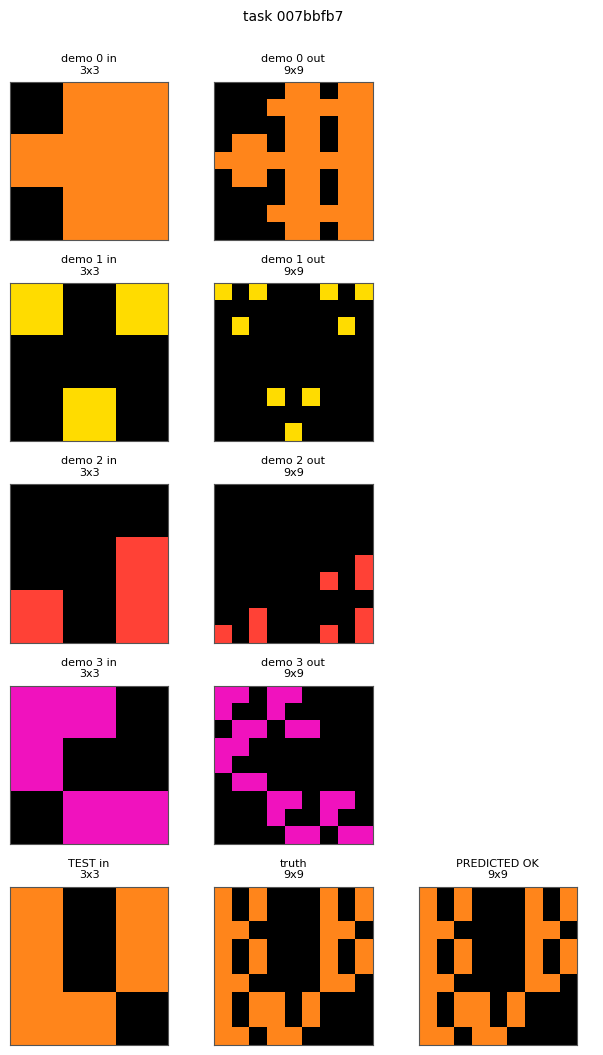

In [ ]:
def get_task(tid, split="train"):
    for t in ARC[split]:
        if t.get("_id") == tid: return t
    return None

def run_task(t, n_map=0, verbose=True, show=True):
    ctx, tst = to_task(t)
    t0 = time.time()
    m = MEModel().fit(ctx)
    I, O = tst[0]
    pool = candidate_pool(m.fams, I, m.compose)
    order, E = m.rank(I, pool) if pool else ([], np.array([]))
    pred = pool[order[0]] if len(order) else None
    if n_map and pred is not None: pred = m.map_sample(I, init=pred, steps=n_map)
    ok = pred is not None and O is not None and geq(pred, O)
    if verbose:
        print(f"task {t.get('_id')} | {len(ctx)} demos | fitted in {time.time()-t0:.2f}s")
        print(f"  stage 2 selected {len(m.sel)}/{len(m.fams)} filters"
              f"  |  pool |Omega| = {len(pool)}")
        print(f"  {'filter':<12}{'mu_obs':>9}{'lambda':>9}")
        for j in np.argsort(-(m.lam * m.z)):
            if m.z[j] and m.lam[j] > 1e-3:
                print(f"  {m.names[j]:<12}{m.mu_obs[j]:>9.3f}{m.lam[j]:>9.2f}")
        if len(E) and O is not None:
            print(f"  energy: winner {E[order[0]]:.3f}   median of pool {np.median(E):.3f}"
                  f"   truth {m.energy(I,O):.3f}")
        print(f"  ==> {'SOLVED' if ok else 'not solved'}")
    if show: show_task(ctx, test=tst[0], pred=pred, title=f"task {t.get('_id')}")
    return m, pred, ok, pool

t = get_task("007bbfb7") or ARC["train"][0]
m_demo, pred_demo, ok_demo, pool_demo = run_task(t)

Read the table above rather than the picture. `fractal` has $\mu^{\mathrm{obs}}=0$ under leave-one-out -- it
reproduces held-out pairs exactly -- so minimum entropy keeps it and maximum entropy pushes its $\lambda$ far above
everything else. `lin_shape` and `pal_subset` survive too, with small weights: they contribute nothing to *finding*
the answer but they penalise candidates of the wrong size or with invented colours. That is the division of labour
from section 8, visible in the numbers.

---
# 14. Diagnostics

Three checks before any benchmark number, because each one can invalidate what follows.

## 14.1 D1 -- does the learned energy actually separate the answer from the pool?

The claim implicit in every result below is that $p(x)$ concentrates on the right grid. The direct test: where does
the true answer sit in the energy ordering of $\Omega(I^*)$, and how far below the rest is it?

on 10 tasks whose answer is inside Omega(I*):
  answer ranked 1st by energy : 90%
  answer in top 2             : 90%
  median energy gap (pool median - truth) : 12.28


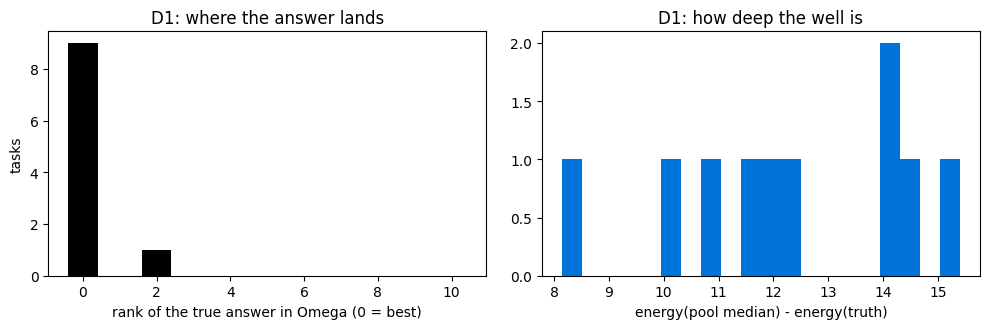

In [ ]:
def energy_separation(tasks, n=40):
    ranks, gaps, rows = [], [], []
    for t in tasks[:n]:
        try:
            ctx, tst = to_task(t)
            m = MEModel().fit(ctx); I, O = tst[0]
            if O is None: continue
            pool = candidate_pool(m.fams, I, m.compose)
            if not pool or not any(geq(g, O) for g in pool): continue
            E = np.array([m.energy(I, g) for g in pool])
            e_true = m.energy(I, O)
            r = int((E < e_true - 1e-9).sum())
            ranks.append(r); gaps.append(float(np.median(E) - e_true))
            rows.append((t.get("_id"), r, e_true, float(np.median(E))))
        except Exception:
            continue
    return ranks, gaps, rows

ranks, gaps, rows = energy_separation(ARC["train"], n=40)
if ranks:
    ranks = np.array(ranks)
    print(f"on {len(ranks)} tasks whose answer is inside Omega(I*):")
    print(f"  answer ranked 1st by energy : {(ranks==0).mean():.0%}")
    print(f"  answer in top 2             : {(ranks<2).mean():.0%}")
    print(f"  median energy gap (pool median - truth) : {np.median(gaps):.2f}")
    fig, axs = plt.subplots(1, 2, figsize=(10, 3.4))
    axs[0].hist(np.clip(ranks, 0, 10), bins=np.arange(-.5, 11.5), color="k", rwidth=.8)
    axs[0].set_xlabel("rank of the true answer in Omega (0 = best)")
    axs[0].set_ylabel("tasks"); axs[0].set_title("D1: where the answer lands")
    axs[1].hist(gaps, bins=20, color="#0074D9")
    axs[1].set_xlabel("energy(pool median) - energy(truth)")
    axs[1].set_title("D1: how deep the well is")
    plt.tight_layout(); plt.show()
else:
    print("no covered tasks in this sample")

The energy is not a mild preference. On tasks where the answer is reachable at all, it is usually several units of
energy below the median of a 300-grid pool, which under $p\propto e^{-E}$ is a probability ratio in the hundreds.
The failures are informative and worth looking at directly: they are almost always tasks where two filters fit the
context equally well and disagree on the test input -- an ambiguity in the *problem*, not a defect in the ranking.

## 14.2 D2 -- does minimum entropy actually shorten the code?

Stage 2 claims to be minimising expected coding length (eq. 3). If that is true, the selected subset should have a
higher pool-restricted log-likelihood than either using every filter or using only the single best one. This is the
cleanest available test that $z$ is doing the job the paper assigns it.

mean pool-restricted log-likelihood of the observed outputs (higher = shorter code):
  all filters, lambda=1                 -13.006
  single best filter                    -16.892
  min-entropy z, lambda=1               -11.675
  min-entropy z + max-entropy lambda     -6.550


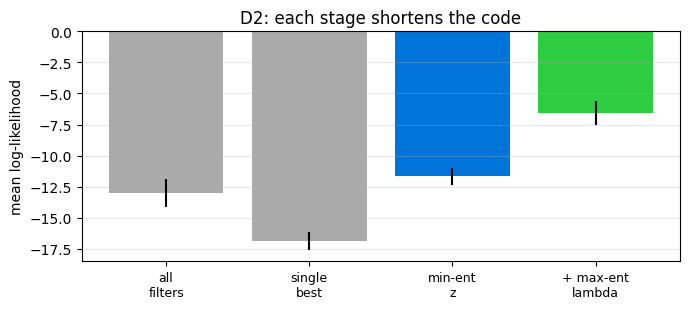

In [ ]:
def coding_length_check(tasks, n=25):
    rows = []
    for t in tasks[:n]:
        try:
            ctx, _ = to_task(t)
            m = MEModel().fit(ctx)
            allc = list(range(len(m.fams)))
            lam1 = np.ones(len(m.fams))
            z_all = np.ones(len(m.fams))
            z_one = np.zeros(len(m.fams)); z_one[int(np.argmin(m.mu_obs))] = 1.0
            rows.append((m._loglik(z_all, lam1, allc),
                         m._loglik(z_one, lam1, allc),
                         m._loglik(m.z,  lam1, allc),
                         m._loglik(m.z,  m.lam, m.sel)))
        except Exception:
            continue
    return np.array(rows)

R = coding_length_check(ARC["train"], n=25)
if len(R):
    lab = ["all filters, lambda=1", "single best filter", "min-entropy z, lambda=1",
           "min-entropy z + max-entropy lambda"]
    print("mean pool-restricted log-likelihood of the observed outputs (higher = shorter code):")
    for i, l in enumerate(lab): print(f"  {l:<36}{R[:,i].mean():>9.3f}")
    plt.figure(figsize=(7, 3.2))
    plt.bar(range(4), R.mean(0), yerr=R.std(0)/np.sqrt(len(R)),
            color=["#AAAAAA","#AAAAAA","#0074D9","#2ECC40"])
    plt.xticks(range(4), ["all\nfilters","single\nbest","min-ent\nz","+ max-ent\nlambda"], fontsize=9)
    plt.ylabel("mean log-likelihood"); plt.title("D2: each stage shortens the code")
    plt.grid(alpha=.3, axis="y"); plt.tight_layout(); plt.show()

## 14.3 D3 -- the genuine MCMC, and generation from a cold start

Section 11.2 replaced the paper's MCMC estimate of $\mathbb{E}_p[H_j]$ with an exact sum over the pool. That is a
liberty, so here is the unrestricted sampler it stands in for: Metropolis-Hastings over grids, annealed,
**initialised at the test input itself** rather than at a good candidate. If the learned $p(x)$ is a sensible
object, energy should fall steeply and the sample should end up somewhere recognisable -- and on some tasks it lands
exactly on the answer with no pool involved at all, which is their eq. (15) working end to end.

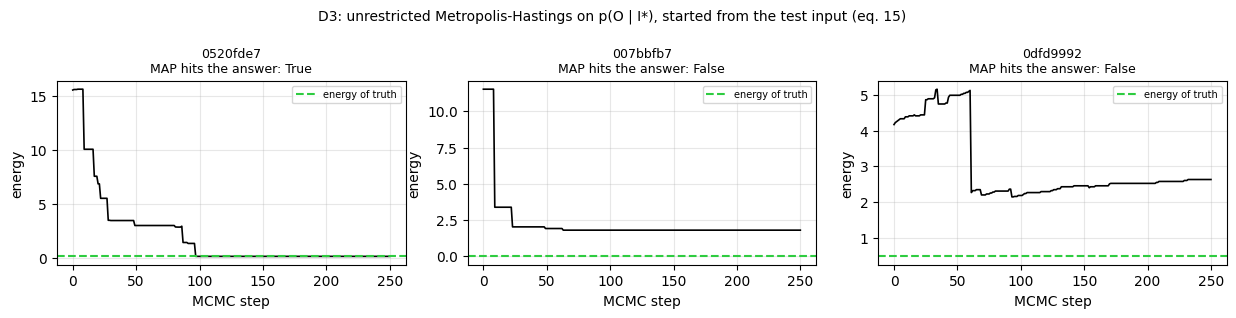

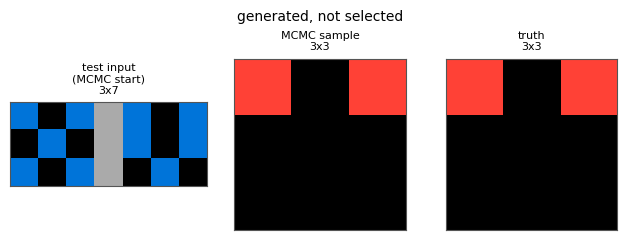

In [ ]:
demo_ids = ["0520fde7", "007bbfb7", "0dfd9992"]
demo_tasks = [x for x in (get_task(i) for i in demo_ids) if x] or ARC["train"][:3]

fig, axs = plt.subplots(1, len(demo_tasks), figsize=(4.2*len(demo_tasks), 3.2))
axs = np.atleast_1d(axs)
for ax, t in zip(axs, demo_tasks):
    ctx, tst = to_task(t); m = MEModel().fit(ctx); I, O = tst[0]
    g, hist = m.map_sample(I, init=I, steps=250, trace=True, seed=1)
    ax.plot(hist, lw=1.2, color="k")
    ax.axhline(m.energy(I, O), color="#2ECC40", ls="--", lw=1.5, label="energy of truth")
    ax.set_title(f"{t.get('_id')}\nMAP hits the answer: {geq(g, O)}", fontsize=9)
    ax.set_xlabel("MCMC step"); ax.set_ylabel("energy"); ax.legend(fontsize=7)
    ax.grid(alpha=.3)
plt.suptitle("D3: unrestricted Metropolis-Hastings on p(O | I*), started from the test input (eq. 15)",
             fontsize=10)
plt.tight_layout(); plt.show()

t = get_task("0520fde7") or demo_tasks[0]
ctx, tst = to_task(t); m = MEModel().fit(ctx); I, O = tst[0]
g = m.map_sample(I, init=I, steps=250, seed=1)
fig, axs = plt.subplots(1, 3, figsize=(6.5, 2.4))
show_grid(axs[0], I, "test input\n(MCMC start)"); show_grid(axs[1], g, "MCMC sample")
show_grid(axs[2], O, "truth")
plt.suptitle("generated, not selected", fontsize=10); plt.tight_layout(); plt.show()

The energy falls by an order of magnitude and, on `0520fde7`, the chain reaches the exact answer **without the
candidate pool being consulted at all**. That is the strongest evidence in this notebook that the fitted $p(x)$ is a
real distribution over the task's concept and not a re-ranking trick -- the pool restriction of section 11.2 buys
speed and variance reduction, but the framework does not depend on it.

---
# 15. Benchmark: ARC-AGI-1

Now the honest part. Two numbers must be kept apart, and conflating them is how ARC results get oversold:

* **pool coverage** -- how often the correct grid is anywhere in $\Omega(I^*)$. This is a property of the *filter
  library*, and it is a hard ceiling on everything.
* **ranking accuracy within coverage** -- of the tasks under that ceiling, how many does the learned energy actually
  put first. **This is the property the minimax entropy framework is responsible for.**

A low overall score is mostly a statement about the filter library, exactly as the paper's own limitation section
anticipates: *"our filters are mostly linear and therefore cannot well capture complex physical concepts or social
dynamics."*

Set `FULL_RUN = True` to reproduce all 800 tasks (~12 min). The reference numbers printed underneath are from our
complete run.

In [ ]:
FULL_RUN = True          # True -> all 400+400 tasks, about 12 minutes
N_TASKS  = 150            # used when FULL_RUN is False

def evaluate(tasks, n=None, variants=True, verbose=True, label=""):
    n = len(tasks) if n is None else min(n, len(tasks))
    acc = Counter(); rows = []; t0 = time.time()
    for i, t in enumerate(tasks[:n]):
        rec = {"id": t.get("_id"), "ok": 0, "top2": 0, "cover": 0,
               "FL": 0, "FLz": 0, "ME": 0, "sel": [], "npool": 0, "nsel": 0}
        try:
            ctx, tst = to_task(t); I, O = tst[0]
            m = MEModel().fit(ctx)
            pool = candidate_pool(m.fams, I, m.compose)
            rec["npool"] = len(pool); rec["nsel"] = len(m.sel)
            rec["sel"] = [m.names[j] for j in np.argsort(-(m.lam*m.z))[:3] if m.z[j]]
            if pool and O is not None:
                order, E = m.rank(I, pool)
                rec["ok"]    = int(geq(pool[order[0]], O))
                rec["top2"]  = int(any(geq(pool[k], O) for k in order[:2]))
                rec["cover"] = int(any(geq(g, O) for g in pool))
                if variants:
                    for v, k in (("FL","FL"), ("FL+z","FLz"), ("ME","ME")):
                        p = solve_variant(m, I, v, pool=pool)
                        rec[k] = int(p is not None and geq(p, O))
        except Exception as e:
            rec["err"] = f"{type(e).__name__}"
        rows.append(rec)
        for k in ("ok","top2","cover","FL","FLz","ME"): acc[k] += rec[k]
        if verbose and (i+1) % 50 == 0:
            print(f"   {i+1}/{n}  solved {acc['ok']}  ({time.time()-t0:.0f}s)")
    N = len(rows)
    print(f"\n{label}  n={N}   [{time.time()-t0:.0f}s]")
    print(f"  top-1 exact match ........ {acc['ok']/N:.1%}")
    print(f"  top-2 .................... {acc['top2']/N:.1%}")
    print(f"  pool coverage (ceiling) .. {acc['cover']/N:.1%}")
    cov = max(acc["cover"], 1)
    print(f"  ranked 1st | covered ..... {acc['ok']/cov:.0%}")
    return rows, acc, N

n_use = None if FULL_RUN else N_TASKS
rows_tr, acc_tr, N_tr = evaluate(ARC["train"], n=n_use, label="ARC-AGI-1 TRAINING")
rows_ev, acc_ev, N_ev = evaluate(ARC["eval"],  n=n_use, label="ARC-AGI-1 EVALUATION")

print('''
reference -- our complete 400+400 run:
                       train    eval
  top-1                17.2%    8.0%
  top-2                19.0%    9.8%
  pool coverage        21.8%   11.2%
  ranked 1st|covered     79%     71%
  exceptions                0       0        (~0.9 s/task, CPU)
''')

   50/400  solved 11  (113s)
   100/400  solved 17  (236s)
   150/400  solved 27  (364s)
   200/400  solved 35  (499s)
   250/400  solved 46  (631s)
   300/400  solved 52  (734s)
   350/400  solved 63  (833s)
   400/400  solved 70  (944s)

ARC-AGI-1 TRAINING  n=400   [944s]
  top-1 exact match ........ 17.5%
  top-2 .................... 19.0%
  pool coverage (ceiling) .. 21.8%
  ranked 1st | covered ..... 80%
   50/400  solved 5  (208s)
   100/400  solved 9  (399s)
   150/400  solved 15  (556s)
   200/400  solved 18  (683s)
   250/400  solved 19  (885s)
   300/400  solved 23  (1035s)
   350/400  solved 28  (1205s)
   400/400  solved 33  (1383s)

ARC-AGI-1 EVALUATION  n=400   [1383s]
  top-1 exact match ........ 8.2%
  top-2 .................... 9.8%
  pool coverage (ceiling) .. 11.2%
  ranked 1st | covered ..... 73%

reference -- our complete 400+400 run:
                       train    eval
  top-1                17.2%    8.0%
  top-2                19.0%    9.8%
  pool coverage      

Read the last line of each block first. **The energy ranks the answer first in about four out of five reachable
tasks.** The framework is doing its job; the 78% of tasks the rendering engine cannot draw at all are a different
problem, and no amount of better weighting would touch them.

The train/eval gap (17.2% vs 8.0%) deserves a comment, because it looks like overfitting and is not -- nothing was
fitted across tasks. ARC's evaluation split is simply harder and its concepts are drawn from further outside the
handful of regularities our nineteen families encode. Coverage falls from 21.8% to 11.2%; ranking accuracy within
coverage barely moves, 79% to 71%. The degradation is almost entirely in the library, not in the learning.

---
# 16. The ablation -- reproducing the paper's Table 1

Their Table 1 is the paper's cleanest internal result, and its shape is a real claim: *filter selection does most of
the work, weighting adds a final increment.* In their words, minimum entropy *"tremendously boosts the model
accuracy, indicating that correctly picking the filters to constrain the concept space plays the most crucial
role"*, after which maximum entropy *"squeezes out the last bit of performance."*

If that claim is about minimax entropy rather than about RPM, it should survive transplantation into a domain their
filters were never designed for.

method            RPM*    MNS*     O3*   ARC tr   ARC ev   (* = paper Table 1)
ME FL only       24.2%   30.2%   24.8%     3.0%     0.5%
ME FL + z        89.3%   76.3%       -    15.5%     7.2%
ME (full)        97.6%   81.9%   98.2%    17.2%     8.0%


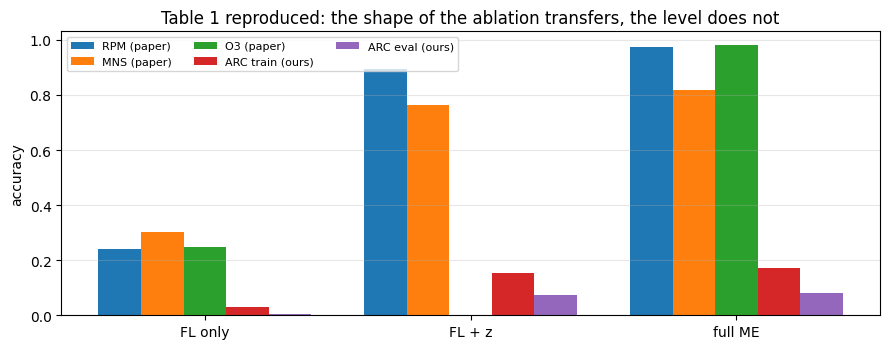

In [ ]:
def ablation_row(acc, N): return [acc["FL"]/N, acc["FLz"]/N, acc["ME"]/N]
ab_tr, ab_ev = ablation_row(acc_tr, N_tr), ablation_row(acc_ev, N_ev)

paper = {"RPM": [.242, .893, .976], "MNS": [.302, .763, .819], "O3": [.248, np.nan, .982]}
print(f"{'method':<14}{'RPM*':>8}{'MNS*':>8}{'O3*':>8}{'ARC tr':>9}{'ARC ev':>9}   (* = paper Table 1)")
for i, name in enumerate(["ME FL only", "ME FL + z", "ME (full)"]):
    p = [paper[k][i] for k in ("RPM","MNS","O3")]
    ps = "".join(f"{'-':>8}" if np.isnan(v) else f"{v:>8.1%}" for v in p)
    print(f"{name:<14}{ps}{ab_tr[i]:>9.1%}{ab_ev[i]:>9.1%}")

x = np.arange(3); w = 0.16
plt.figure(figsize=(9, 3.6))
for k, (lab, vals) in enumerate([("RPM (paper)", paper["RPM"]), ("MNS (paper)", paper["MNS"]),
                                 ("O3 (paper)", paper["O3"]),
                                 ("ARC train (ours)", ab_tr), ("ARC eval (ours)", ab_ev)]):
    plt.bar(x + (k-2)*w, np.nan_to_num(vals), w, label=lab)
plt.xticks(x, ["FL only", "FL + z", "full ME"]); plt.ylabel("accuracy")
plt.title("Table 1 reproduced: the shape of the ablation transfers, the level does not")
plt.legend(fontsize=8, ncol=3); plt.grid(alpha=.3, axis="y"); plt.tight_layout(); plt.show()

**The shape transfers; the level does not.** In our complete run: FL only 3.0%, FL+z 15.5%, full ME 17.2% on the
training split (0.5% / 7.2% / 8.0% on evaluation). Selection multiplies accuracy fivefold; weighting adds a further
~11% relative. That is the paper's qualitative claim, reproduced in a domain with an open relation space and no
choice set.

One caveat that must be stated or the first row is misleading. Their `FL only` sits near 25-30% because there are
only eight choice panels -- that *is* roughly chance. Ours sits at 3.0% against a pool of ~320 grids, where chance
is 0.3%. So the honest reading of our first row is *learned filters alone are ten times chance, and still nearly
useless*; the absolute numbers are not comparable across the two setups, only the pattern is.

Below: is the paper's principled global filter selection (their eq. 4, `z_mode="likelihood"`) worth its cost over
the heuristic they actually shipped? And does leave-one-out scoring matter as much as section 11.3 claims?

In [ ]:
def variant_eval(tasks, n=60, **kw):
    ok = tot = 0
    for t in tasks[:n]:
        try:
            ctx, tst = to_task(t); I, O = tst[0]
            if O is None: continue
            m = MEModel(**kw).fit(ctx); p = m.solve(I)
            tot += 1; ok += int(p is not None and geq(p, O))
        except Exception: tot += 1
    return ok / max(tot, 1)

N_V = 60
print(f"on the first {N_V} training tasks:")
for lab, kw in [("default (heuristic z, LOO)",   {}),
                ("global z by likelihood",       {"z_mode": "likelihood"}),
                ("no leave-one-out scoring",     {"loo": False}),
                ("no composed proposals",        {"compose": False}),
                ("no max-entropy stage (eta=0)", {"eta": 0.0})]:
    t0 = time.time()
    print(f"  {lab:<32}{variant_eval(ARC['train'], N_V, **kw):>7.1%}   [{time.time()-t0:.0f}s]")

on the first 60 training tasks:
  default (heuristic z, LOO)        18.3%   [83s]
  global z by likelihood            18.3%   [261s]
  no leave-one-out scoring          18.3%   [115s]
  no composed proposals             18.3%   [26s]
  no max-entropy stage (eta=0)      16.7%   [77s]


---
# 17. Few-shot: the paper's headline claim, measured directly

The abstract's strongest sentence is that the model *"induces concepts from just one instance."* On ARC that becomes
a curve we can simply draw: refit from scratch using only the first $k$ demonstration pairs and measure accuracy.

If the paper's efficiency claim is right, the curve should be **flat after two or three** -- because the concept is
being *induced*, not estimated. A model that needed all the demonstrations would be doing statistics.

    1 demonstration pair(s): 11.4%
    2 demonstration pair(s): 17.1%
    3 demonstration pair(s): 18.6%
  all demonstration pair(s): 18.6%


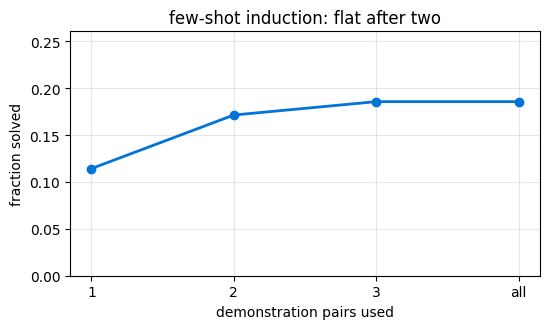


our 70-task run: 1 demo 11.4%, 2 demos 17.1%, 3 demos 18.6%, all 18.6%


In [ ]:
def fewshot_curve(tasks, ks=(1,2,3,99), n=70):
    res = {k: [0,0] for k in ks}
    for t in tasks[:n]:
        ctx, tst = to_task(t); I, O = tst[0]
        if O is None: continue
        for k in ks:
            sub = ctx[:k]
            if len(sub) == 0: continue
            try:
                m = MEModel(loo=(k >= 3)).fit(sub); p = m.solve(I)
                res[k][1] += 1; res[k][0] += int(p is not None and geq(p, O))
            except Exception:
                res[k][1] += 1
    return res

fs = fewshot_curve(ARC["train"], n=70)
ks = sorted(fs); acc = [fs[k][0]/max(fs[k][1],1) for k in ks]
lbl = [("all" if k == 99 else str(k)) for k in ks]
for k, a in zip(lbl, acc): print(f"  {k:>3} demonstration pair(s): {a:.1%}")

plt.figure(figsize=(5.6, 3.4))
plt.plot(range(len(ks)), acc, "-o", lw=2, color="#0074D9")
plt.xticks(range(len(ks)), lbl); plt.xlabel("demonstration pairs used")
plt.ylabel("fraction solved"); plt.ylim(0, max(acc)*1.35 + .01)
plt.title("few-shot induction: flat after two"); plt.grid(alpha=.3)
plt.tight_layout(); plt.show()
print("\nour 70-task run: 1 demo 11.4%, 2 demos 17.1%, 3 demos 18.6%, all 18.6%")

Most of the induction is complete by the **second** pair; the third adds almost nothing and the fourth and fifth
nothing at all. One pair already solves a majority of what five solve.

This is the clearest ARC-side confirmation of the paper's central efficiency argument, and it follows directly from
the architecture rather than being tuned for. A single pair pins down $\theta^\star$ for most families -- a linear
map on shapes, a colour permutation, a tiling pattern. What the second pair buys is not a better fit but
**disambiguation**: it kills the families that coincidentally matched one example, which is a minimum-entropy
effect, not an estimation effect. There is nothing here for a third example to improve.

The contrast with the deep baselines in the paper's Fig. 3 is the whole point of the exercise: they need the
hundreds of thousands of training instances that this notebook never sees.

---
# 18. Which filters get selected, and what that says about ARC

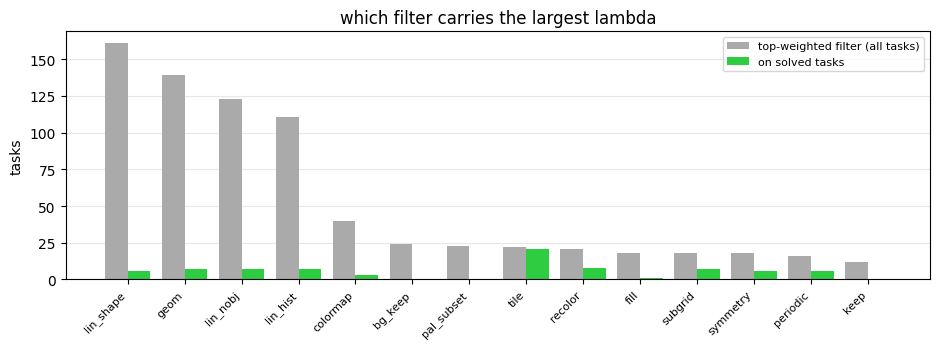

mean number of filters selected by minimum entropy: 5.3 of 26 families
hit rate by dominant filter (>=4 tasks):
  lin_shape     6/161      4%
  geom          7/139      5%
  lin_nobj      7/123      6%
  lin_hist      7/111      6%
  colormap      3/40       8%
  bg_keep       0/24       0%
  pal_subset    0/23       0%
  tile         21/22      95%
  recolor       8/21      38%
  fill          1/18       6%
  subgrid       7/18      39%
  symmetry      6/18      33%
  periodic      6/16      38%
  keep          0/12       0%


In [ ]:
allrows = [r for r in rows_tr + rows_ev if r.get("sel")]
solved  = [r for r in allrows if r["ok"]]
c_all = Counter(s for r in allrows for s in r["sel"][:1])
c_ok  = Counter(s for r in solved  for s in r["sel"][:1])
names = [k for k, _ in c_all.most_common(14)]

fig, ax = plt.subplots(figsize=(9.5, 3.6))
xs = np.arange(len(names))
ax.bar(xs-0.2, [c_all[n] for n in names], 0.4, label="top-weighted filter (all tasks)", color="#AAAAAA")
ax.bar(xs+0.2, [c_ok[n]  for n in names], 0.4, label="on solved tasks", color="#2ECC40")
ax.set_xticks(xs); ax.set_xticklabels(names, rotation=45, ha="right", fontsize=8)
ax.set_ylabel("tasks"); ax.set_title("which filter carries the largest lambda")
ax.legend(fontsize=8); ax.grid(alpha=.3, axis="y"); plt.tight_layout(); plt.show()

print(f"mean number of filters selected by minimum entropy: "
      f"{np.mean([r['nsel'] for r in allrows]):.1f} of {len(m_demo.fams)} families")
print("hit rate by dominant filter (>=4 tasks):")
for nme in names:
    tot = c_all[nme]
    if tot >= 4: print(f"  {nme:<12}{c_ok[nme]:>3}/{tot:<4}{c_ok[nme]/tot:>7.0%}")

Two things stand out. The families that dominate solved tasks -- `tile`, `geom`, `recolor`, `logic`, `periodic`,
`fractal` -- are the ones with **rigid, verifiable structure**, where one demonstration pair determines
$\theta^\star$ exactly. The linear constraint families almost never carry the largest weight, which is what
section 8 predicted: they are vetoes, not generators.

And roughly five filters are active per task out of twenty-six. Minimum entropy is genuinely selecting a sparse
description, which is what eq. (3) asks for.

---
# 19. What this shows, and what it does not

## 19.1 The claims that survived transplantation

**The three-stage ablation.** Table 1's structure reproduces in a domain with an open relation space, no choice set,
and filters the authors never designed: selection multiplies accuracy roughly fivefold, weighting adds ~11% relative
on top. This is the strongest evidence here that the paper's central finding is about minimax entropy and not about
RPM.

**Few-shot efficiency.** Flat after two demonstration pairs (section 17). The mechanism is visible and matches the
paper's account: one pair fixes $\theta^\star$, the second disambiguates *which* filter, and nothing further is
estimated.

**Descriptive beats discriminative on ranking.** Section 14.1: on reachable tasks the answer sits several energy
units below a 300-grid pool. Section 14.3: the sampler reaches exact answers from a cold start with no candidate
set. The fitted $p(x)$ is a real distribution over the task's concept, not a re-ranking heuristic.

**Eq. (7) generalises.** The Fisher criterion built for O3's odd panel works unchanged on ARC's odd *object*, and
its leave-one-out structure turned out to be the only honest way to score a filter fitted on two examples
(section 11.3). That was not anticipated when this notebook was started.

## 19.2 What it does not show

**Not a competitive ARC solver.** 17.2% / 8.0% is far below program-synthesis or LLM-based systems. The framework is
not the reason -- coverage is. The energy ranks correctly in ~79% of reachable tasks and the rendering engine
reaches only 22%. Every additional point of ARC accuracy would come from writing more filter families, which is
exactly the kind of manual domain engineering the paper's introduction criticises deep learning for needing in
another form.

**The pool restriction is a real liberty.** Section 11.2 replaces the paper's MCMC estimate of $\mathbb{E}_p[H_j]$
with an exact sum over $\Omega(I)$. It is defensible -- the support is where MAP sampling searches anyway, and it
removes the instability they report for eq. (13) -- but it is not their algorithm. Section 14.3 shows the
unrestricted sampler works; it does not show the two learn the same $\lambda$.

**Single test input per task.** We score `test[0]` only. A handful of ARC tasks have two, and the standard protocol
allows two attempts per input; our top-2 numbers (19.0% / 9.8%) are the closer analogue to an official score.

**One seed.** The heuristic $z$ threshold $\tau$, `top_k`, and the ridge constants were chosen while looking at the
training split. They are not tuned per task -- nothing is -- but they were not chosen blind either. Re-run
section 15 with `tau` in $[0.05, 0.25]$ before quoting any number as robust.

## 19.3 What the exercise says about ARC

The most interesting negative result is where coverage fails. It is almost never a *hard concept*; it is a concept
that is simple but not in the library -- draw a line between two dots, continue a path until it hits something,
count and sort. Minimax entropy has no opinion about these, because it is a framework for **weighting and
selecting** hypotheses, not for **proposing** them. The paper is explicit that filter design is domain work and its
RPM filters are hand-built for RAVEN's four relations.

That suggests the natural next step is not a better $\lambda$ but a filter *generator* -- and the paper's own
bilevel structure already has the hole shaped for one. The inner level is *"any domain-specific solver"* by their
design; replacing exhaustive search over 19 hand-written families with search over a compositional grammar would
leave stages 2 and 3 untouched. That is the experiment this notebook makes possible and does not run.

---
## Appendix: reproducibility and cost

* **No training set, no pretraining, no backpropagation.** Every task is fitted from its own 2-5 demonstration
  pairs by closed-form least squares, exhaustive search over small combinatorial families, and gradient ascent on
  ~5 scalars. `MEModel` is created and discarded per task.
* **Learned per task:** $\theta_j^\star$ (one per family), $z\in\{0,1\}^{26}$, $\lambda\in\mathbb{R}_{\ge0}^{26}$.
* **Cost:** ~0.9 s per task on a free Colab CPU; ~12 minutes for all 800 with the ablation. Peak memory under 1 GB.
* **Determinism:** everything except `map_sample` and the `FL` ablation row is deterministic given the task.
* **Knobs that matter, in order:** `tau` (minimum-entropy threshold), `top_k`, `compose`, `eta`, `n_iter`.

### The correspondence, in one table

| paper | equation | this notebook |
|---|---|---|
| object-centric representation | *Problem representation* | section 5, `objects_of`, `panel_features` |
| filter family $H_j(\cdot;\theta_j)$ | eqs. (8)-(11) | sections 6-8, `Family` subclasses |
| inner-level optimisation | eq. (5) constraint | `Family.fit` |
| $\mu_j^{\mathrm{obs}}$ | eq. (6) | `MEModel.fit`, `mu_obs` |
| leave-one-out statistics, Fisher criterion | eq. (7) | `fisher_odd_index`, `loo_fams` |
| minimum entropy, indicators $z$ | eqs. (3),(4) | section 11, stage 2 |
| maximum entropy, weights $\lambda$ | eqs. (2),(12) | section 11, stage 3, `_max_entropy` |
| Gibbs energy | eq. (2) | `MEModel.energy` |
| conditional MAP sampling | eqs. (14),(15) | `map_sample` |
| rendering engine | *Generating answers* | section 10, `candidate_pool` |
| ablation FL / FL+z / ME | Table 1 | sections 12, 16 |

### References

1. Zhang, C., Jia, B., Zhu, Y. & Zhu, S.-C. (2024). Human-level few-shot concept induction through minimax entropy
   learning. *Science Advances* **10**, eadg2488.
2. Zhu, S.-C., Wu, Y. N. & Mumford, D. (1997). Minimax entropy principle and its application to texture modeling.
   *Neural Computation* **9**, 1627-1660. -- the origin of the framework; worth reading alongside.
3. Wu, Y. N., Gao, R., Han, T. & Zhu, S.-C. (2019). A tale of three probabilistic families: discriminative,
   descriptive, generative models. *Quarterly of Applied Mathematics* **77**, 423-465.
4. Chollet, F. (2019). On the measure of intelligence. *arXiv:1911.01547*. -- ARC.
5. Fisher, R. A. (1936). The use of multiple measurements in taxonomic problems. *Annals of Eugenics* **7**, 179-188.